# ¿Puede un mapa de calor decirle a la policía dónde patrullar?

**Focalización del delito para la Policía Metropolitana de Bogotá**

---

La Policía Metropolitana de Bogotá evalúa reemplazar el patrullaje uniforme por un protocolo de focalización en puntos calientes. La pregunta que este análisis debe responder es **qué procedimiento de focalización adoptar**, y **qué parte de lo aprendido es transferible entre ciudades distintas**.

Usamos datos de Chicago del verano de 2019 como banco de pruebas. La aclaración es importante desde el principio: **lo que se transfiere a Bogotá no son los puntos calientes de Chicago sino el comportamiento de los procedimientos**. Ningún patrullero de Bogotá va a ir a Englewood. Lo que sí viaja es saber, por ejemplo, si contar delitos por barrio y estimar una densidad identifican los mismos lugares o lugares distintos, porque eso depende de cómo funciona cada método y volverá a ocurrir en cualquier ciudad.

In [1]:
# ==============================================================================
#                        LIBRERIAS Y PARAMETROS
# ==============================================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import folium

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.width", 160)

# Reproducibilidad exigida por el enunciado
RANDOM_STATE = 123
np.random.seed(RANDOM_STATE)

# Sistemas de coordenadas
CRS_GEO = "EPSG:4326"        # WGS84, grados: el que traen los datos
CRS_METRICO = "EPSG:26971"   # NAD83 / Illinois East, metros: para areas y distancias

# Centro de la ciudad que fija el enunciado (lon, lat)
CENTRO_LON, CENTRO_LAT = -87.627800, 41.881998

print(f"geopandas {gpd.__version__} | folium {folium.__version__}")

geopandas 1.1.4 | folium 0.20.0


## 1.1 Carga de los datos

Dos fuentes: los delitos georreferenciados y los polígonos de las 77 áreas comunitarias en que se divide administrativamente Chicago.

In [2]:
# ==============================================================================
#                           CARGA DE LAS DOS BASES
# ==============================================================================
delitos = pd.read_csv("data/Chicago_delitos_verano_2019.csv")
delitos["fecha"] = pd.to_datetime(delitos["fecha"])

# El shapefile se lee directamente del zip, sin descomprimir
areas = gpd.read_file("zip://data/Areas_comunitarias_Chicago.zip")
areas["area_num"] = areas["area_numbe"].astype(int)
areas = areas.to_crs(CRS_GEO)

print("=" * 78)
print("BASE DE DELITOS")
print("=" * 78)
print(f"Registros : {len(delitos):,}")
print(f"Columnas  : {list(delitos.columns)}")
print(f"Periodo   : {delitos.fecha.min()} a {delitos.fecha.max()}  (hora UTC)")
print(f"Valores faltantes: {delitos.isna().sum().sum()}")
print()
print(delitos.head(3).to_string(index=False))

print()
print("=" * 78)
print("AREAS COMUNITARIAS")
print("=" * 78)
print(f"Poligonos : {len(areas)}")
print(f"CRS       : {areas.crs.name}")
print(f"Geometrias: {areas.geom_type.value_counts().to_dict()}")
print(f"Columnas utiles: area_num, community")

BASE DE DELITOS
Registros : 17,747
Columnas  : ['fecha', 'tipo_crimen', 'nro_area_comunitaria', 'lat', 'lon']
Periodo   : 2019-06-01 05:00:00+00:00 a 2019-09-01 04:48:00+00:00  (hora UTC)
Valores faltantes: 0

                    fecha tipo_crimen  nro_area_comunitaria       lat        lon
2019-06-01 05:07:00+00:00   homicidio                    23 41.897950 -87.728625
2019-06-01 10:09:00+00:00   homicidio                    71 41.753272 -87.648963
2019-06-01 12:46:00+00:00   homicidio                    25 41.877622 -87.750728

AREAS COMUNITARIAS
Poligonos : 77
CRS       : WGS 84
Geometrias: {'Polygon': 76, 'MultiPolygon': 1}
Columnas utiles: area_num, community


**Una precisión sobre las fechas** Las marcas de tiempo vienen en **UTC**, con sufijo `Z`. El rango va del 1 de junio a las 05:00 UTC hasta el 1 de septiembre a las 04:48 UTC, que en hora local de Chicago, cinco horas atrás durante el verano, corresponde exactamente al 1 de junio y al 31 de agosto. El período coincide con lo que anuncia el enunciado.

No afecta este análisis, que es espacial y no horario, pero **cualquier lectura por hora del día exigiría convertir primero**: un delito de las 23:00 hora local aparece como ocurrido al día siguiente en UTC.

In [3]:
# ==============================================================================
#              COMPOSICION DEL DELITO EN EL PERIODO
# ==============================================================================
composicion = delitos.tipo_crimen.value_counts().to_frame("casos")
composicion["porcentaje"] = composicion.casos / len(delitos) * 100

print("=" * 60)
print("COMPOSICION POR TIPO DE DELITO")
print("=" * 60)
print(composicion.to_string())
print("=" * 60)
print(f"Por cada homicidio hay {composicion.loc['robo','casos'] / composicion.loc['homicidio','casos']:.0f} robos")
print(f"Homicidios por area comunitaria, en promedio: "
      f"{composicion.loc['homicidio','casos'] / len(areas):.2f}")

COMPOSICION POR TIPO DE DELITO
             casos  porcentaje
tipo_crimen                   
robo         17603   99.188595
homicidio      144    0.811405
Por cada homicidio hay 122 robos
Homicidios por area comunitaria, en promedio: 1.87


**El desbalance entre los dos delitos es el primer hecho que condiciona todo el análisis.**

Hay **17.603 robos y 144 homicidios**: por cada homicidio se registran 122 robos. Repartidos entre las 77 áreas comunitarias, eso da un promedio de **1,87 homicidios por área** en tres meses.

Esto no es un detalle de contexto sino una restricción estadística. Los procedimientos que vamos a comparar estiman densidades a partir de la ubicación de los eventos, y con 144 puntos para toda una ciudad de 598 km² la estimación va a ser frágil. Lo verificaremos en los pasos siguientes, pero conviene tenerlo presente desde ahora: **no vamos a poder decir lo mismo sobre robos que sobre homicidios**, y esa diferencia es un resultado del análisis y no una limitación que haya que esconder.

## 1.2 Mapa interactivo de las áreas comunitarias

In [4]:
# ==============================================================================
#         MAPA INTERACTIVO DE LAS 77 AREAS COMUNITARIAS
# ==============================================================================
# Conteo por area, para colorear el mapa
conteo_area = (delitos.groupby("nro_area_comunitaria").size()
               .rename("delitos").reset_index())
areas_mapa = areas.merge(conteo_area, left_on="area_num",
                         right_on="nro_area_comunitaria", how="left")
areas_mapa["delitos"] = areas_mapa["delitos"].fillna(0).astype(int)

mapa_areas = folium.Map(location=[CENTRO_LAT, CENTRO_LON], zoom_start=10,
                        tiles="CartoDB positron")

folium.Choropleth(
    geo_data=areas_mapa.to_json(),
    data=areas_mapa,
    columns=["community", "delitos"],
    key_on="feature.properties.community",
    fill_color="YlOrRd",
    fill_opacity=0.7,
    line_opacity=0.4,
    legend_name="Delitos registrados (verano 2019)",
).add_to(mapa_areas)

# Capa transparente con el nombre y el conteo al pasar el mouse
folium.GeoJson(
    areas_mapa.to_json(),
    style_function=lambda x: {"fillColor": "transparent", "color": "transparent"},
    tooltip=folium.GeoJsonTooltip(fields=["community", "delitos"],
                                  aliases=["Área comunitaria:", "Delitos:"]),
).add_to(mapa_areas)

# Marcador del centro que fija el enunciado
folium.Marker([CENTRO_LAT, CENTRO_LON],
              popup="Centro de la ciudad (referencia del Paso 4)",
              icon=folium.Icon(color="blue", icon="star")).add_to(mapa_areas)

mapa_areas

## 1.3 Verificación de la unión entre delitos y polígonos

La base de delitos ya trae una columna con el número de área comunitaria. Antes de usarla conviene **comprobarla contra la geometría**, porque todo el análisis por área depende de que esa asignación sea correcta.

In [5]:
# ==============================================================================
#      ¿COINCIDE EL AREA DECLARADA CON LA QUE CONTIENE AL PUNTO?
# ==============================================================================
delitos_geo = gpd.GeoDataFrame(
    delitos.copy(),
    geometry=gpd.points_from_xy(delitos.lon, delitos.lat),
    crs=CRS_GEO)

union = gpd.sjoin(delitos_geo, areas[["area_num", "community", "geometry"]],
                  how="left", predicate="within")
union = union[~union.index.duplicated(keep="first")]

sin_poligono = union.area_num.isna()
coincide = (union.nro_area_comunitaria == union.area_num)

print("=" * 78)
print("VERIFICACION DE LA UNION ESPACIAL")
print("=" * 78)
print(f"Areas en la base de delitos que faltan en el shapefile: "
      f"{sorted(set(delitos.nro_area_comunitaria) - set(areas.area_num)) or 'ninguna'}")
print(f"Delitos que caen dentro de algun poligono : {(~sin_poligono).sum():,}")
print(f"Delitos que no caen en ninguno            : {sin_poligono.sum():,}")
print(f"Delitos cuya area declarada coincide      : {coincide.sum():,} "
      f"({coincide.mean()*100:.2f}%)")
print("=" * 78)

VERIFICACION DE LA UNION ESPACIAL
Areas en la base de delitos que faltan en el shapefile: ninguna
Delitos que caen dentro de algun poligono : 17,675
Delitos que no caen en ninguno            : 72
Delitos cuya area declarada coincide      : 17,203 (96.93%)


In [6]:
# ==============================================================================
#       ¿SON ERRORES O SON EFECTOS DE BORDE?
# ==============================================================================
areas_m = areas.to_crs(CRS_METRICO).set_index("area_num")
puntos_m = delitos_geo.to_crs(CRS_METRICO)

def distancia_al_area_declarada(indices):
    d = []
    for i in indices:
        a = int(delitos.loc[i, "nro_area_comunitaria"])
        d.append(puntos_m.geometry.loc[i].distance(areas_m.geometry.loc[a]))
    return np.array(d)

discrepantes = union[union.area_num.notna() & ~coincide]
fuera = union[sin_poligono]

d_disc = distancia_al_area_declarada(discrepantes.index)
d_fuera = distancia_al_area_declarada(fuera.index)

# ¿Las dos areas implicadas comparten frontera?
vecinas = sum(
    areas_m.geometry.loc[int(r.nro_area_comunitaria)].touches(
        areas_m.geometry.loc[int(r.area_num)])
    for _, r in discrepantes.iterrows())

print("=" * 78)
print(f"LOS {len(discrepantes)} DELITOS ASIGNADOS A OTRA AREA")
print("=" * 78)
print(f"Distancia al borde del area que declaran (metros):")
print(f"   mediana {np.median(d_disc):.1f} | percentil 90 {np.percentile(d_disc, 90):.1f} "
      f"| maximo {d_disc.max():.1f}")
print(f"A menos de 200 m de su area declarada: {(d_disc <= 200).sum()} de {len(d_disc)} "
      f"({(d_disc <= 200).mean()*100:.0f}%)")
print(f"Casos entre areas que comparten frontera: {vecinas} de {len(discrepantes)} "
      f"({vecinas/len(discrepantes)*100:.0f}%)")
print()
print(f"LOS {len(fuera)} DELITOS QUE NO CAEN EN NINGUN POLIGONO")
print(f"   distancia a su area declarada: mediana {np.median(d_fuera):.1f} m "
      f"| maximo {d_fuera.max():.1f} m")
print("=" * 78)

LOS 472 DELITOS ASIGNADOS A OTRA AREA
Distancia al borde del area que declaran (metros):
   mediana 0.1 | percentil 90 69.8 | maximo 141.9
A menos de 200 m de su area declarada: 472 de 472 (100%)
Casos entre areas que comparten frontera: 472 de 472 (100%)

LOS 72 DELITOS QUE NO CAEN EN NINGUN POLIGONO
   distancia a su area declarada: mediana 0.1 m | maximo 0.2 m


**La unión es correcta y las excepciones se explican por completo.**

El 96,93% de los delitos cae exactamente en el área que declara. De los 544 restantes:

- **Los 472 asignados a otra área lo son siempre a un área vecina**, en el 100% de los casos, y la distancia mediana al borde del área declarada es de **0,1 metros**. Ninguno está a más de 142 metros.
- **Los 72 que no caen en ningún polígono** están a una distancia mediana de 0,1 metros de su área declarada, con un máximo de 0,2 metros. Están literalmente sobre la línea de frontera.

No son errores de la base sino un efecto de la forma en que Chicago publica estos datos, que examinamos en la sección 1.5: las coordenadas se desplazan al centro de la cuadra antes de publicarse, y una cuadra que da a una avenida limítrofe puede quedar milímetros del lado equivocado.

**Decisión: usamos la columna `nro_area_comunitaria` que trae la base**, no la asignación espacial. Es la que usa la propia policía de Chicago para sus reportes, y reasignar 544 casos por diferencias de centímetros introduciría inconsistencias con cualquier cifra oficial sin mejorar nada.

## 1.4 ¿Qué tan concentrado está el delito?

In [7]:
# ==============================================================================
#            TABLA DESCRIPTIVA POR AREA COMUNITARIA
# ==============================================================================
tabla = (delitos.groupby(["nro_area_comunitaria", "tipo_crimen"]).size()
         .unstack(fill_value=0).reset_index())
tabla.columns.name = None
tabla = tabla.merge(areas[["area_num", "community"]],
                    left_on="nro_area_comunitaria", right_on="area_num", how="left")
tabla["total"] = tabla["robo"] + tabla["homicidio"]
tabla = tabla[["nro_area_comunitaria", "community", "robo", "homicidio", "total"]]
tabla = tabla.sort_values("total", ascending=False).reset_index(drop=True)

print("=" * 78)
print("RESUMEN POR AREA COMUNITARIA")
print("=" * 78)
print(tabla[["robo", "homicidio", "total"]].describe().round(1).to_string())
print()
print("Las 10 areas con mas delitos en total:")
print(tabla.head(10).to_string(index=False))

RESUMEN POR AREA COMUNITARIA
         robo  homicidio   total
count    77.0       77.0    77.0
mean    228.6        1.9   230.5
std     284.7        3.1   285.2
min      12.0        0.0    12.0
25%      75.0        0.0    76.0
50%     147.0        0.0   148.0
75%     266.0        2.0   266.0
max    1589.0       15.0  1589.0

Las 10 areas con mas delitos en total:
 nro_area_comunitaria       community  robo  homicidio  total
                   32            LOOP  1589          0   1589
                    8 NEAR NORTH SIDE  1559          0   1559
                   28  NEAR WEST SIDE   912          2    914
                   24       WEST TOWN   798          1    799
                    6       LAKE VIEW   762          1    763
                   25          AUSTIN   671         15    686
                    7    LINCOLN PARK   522          3    525
                   22    LOGAN SQUARE   520          0    520
                   44         CHATHAM   420          4    424
              

CONCENTRACION DEL DELITO ENTRE LAS 77 AREAS
   delito  casos  areas_con_al_menos_1  top5_pct  top10_pct  top20_pct  gini
    total  17747                    77    31.690     46.104     63.137 0.513
     robo  17603                    77    31.926     46.299     63.148 0.513
homicidio    144                    37    38.194     58.333     83.333 0.730


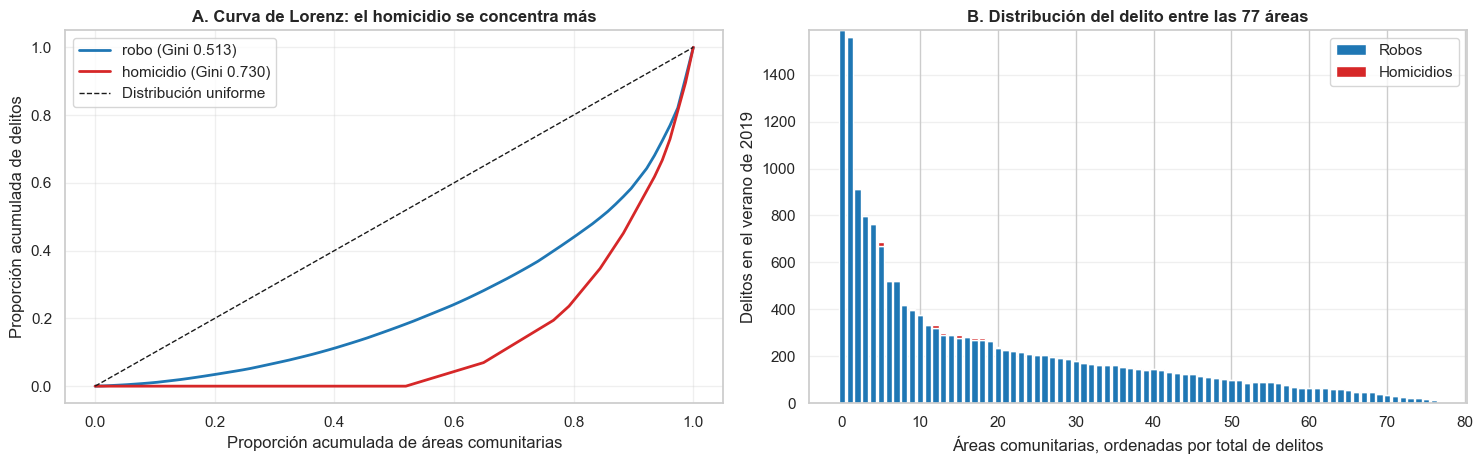

In [8]:
# ==============================================================================
#        CONCENTRACION: CURVA DE LORENZ Y COEFICIENTE DE GINI
# ==============================================================================
def gini(valores):
    s = np.sort(np.asarray(valores, dtype=float))
    n = len(s)
    return (2 * np.arange(1, n + 1) - n - 1).dot(s) / (n * s.sum())

print("=" * 78)
print("CONCENTRACION DEL DELITO ENTRE LAS 77 AREAS")
print("=" * 78)
resumen_conc = []
for col in ["total", "robo", "homicidio"]:
    v = np.sort(tabla[col].values)[::-1]
    resumen_conc.append({
        "delito": col,
        "casos": int(v.sum()),
        "areas_con_al_menos_1": int((v > 0).sum()),
        "top5_pct": v[:5].sum() / v.sum() * 100,
        "top10_pct": v[:10].sum() / v.sum() * 100,
        "top20_pct": v[:20].sum() / v.sum() * 100,
        "gini": gini(tabla[col].values),
    })
print(pd.DataFrame(resumen_conc).to_string(index=False, float_format=lambda x: f"{x:.3f}"))
print("=" * 78)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

for col, color in [("robo", "tab:blue"), ("homicidio", "tab:red")]:
    v = np.sort(tabla[col].values)
    lorenz = np.insert(np.cumsum(v) / v.sum(), 0, 0)
    axes[0].plot(np.linspace(0, 1, len(lorenz)), lorenz, marker="",
                 color=color, lw=2, label=f"{col} (Gini {gini(tabla[col].values):.3f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Distribución uniforme")
axes[0].set_xlabel("Proporción acumulada de áreas comunitarias")
axes[0].set_ylabel("Proporción acumulada de delitos")
axes[0].set_title("A. Curva de Lorenz: el homicidio se concentra más",
                  fontsize=12, fontweight="bold")
axes[0].legend(); axes[0].grid(alpha=0.3)

orden = tabla.sort_values("total", ascending=False)
axes[1].bar(range(len(orden)), orden["robo"], color="tab:blue", label="Robos")
axes[1].bar(range(len(orden)), orden["homicidio"], bottom=orden["robo"],
            color="tab:red", label="Homicidios")
axes[1].set_xlabel("Áreas comunitarias, ordenadas por total de delitos")
axes[1].set_ylabel("Delitos en el verano de 2019")
axes[1].set_title("B. Distribución del delito entre las 77 áreas",
                  fontsize=12, fontweight="bold")
axes[1].legend(); axes[1].grid(alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

In [9]:
# ==============================================================================
#     ¿COINCIDEN LAS AREAS CON MAS ROBOS Y CON MAS HOMICIDIOS?
# ==============================================================================
top_robo = tabla.nlargest(10, "robo")
top_homi = tabla.nlargest(10, "homicidio")

print("=" * 78)
print("TOP 10 POR ROBOS")
print("=" * 78)
print(top_robo[["community", "robo", "homicidio"]].to_string(index=False))
print()
print("=" * 78)
print("TOP 10 POR HOMICIDIOS")
print("=" * 78)
print(top_homi[["community", "homicidio", "robo"]].to_string(index=False))
print()
comunes = set(top_robo.community) & set(top_homi.community)
print("=" * 78)
print(f"Areas presentes en ambos top 10: {len(comunes)} -> {sorted(comunes)}")
print(f"Homicidios en las dos areas con mas robos "
      f"({top_robo.iloc[0].community} y {top_robo.iloc[1].community}): "
      f"{int(top_robo.iloc[0].homicidio)} y {int(top_robo.iloc[1].homicidio)}")
print("=" * 78)

TOP 10 POR ROBOS
      community  robo  homicidio
           LOOP  1589          0
NEAR NORTH SIDE  1559          0
 NEAR WEST SIDE   912          2
      WEST TOWN   798          1
      LAKE VIEW   762          1
         AUSTIN   671         15
   LINCOLN PARK   522          3
   LOGAN SQUARE   520          0
        CHATHAM   420          4
    SOUTH SHORE   397          6

TOP 10 POR HOMICIDIOS
             community  homicidio  robo
                AUSTIN         15   671
         HUMBOLDT PARK         12   319
        NORTH LAWNDALE         12   277
GREATER GRAND CROSSING          9   289
              ROSELAND          7   270
           SOUTH SHORE          6   397
          CHICAGO LAWN          6   270
    EAST GARFIELD PARK          6   235
         SOUTH CHICAGO          6   153
        WEST ENGLEWOOD          5   289

Areas presentes en ambos top 10: 2 -> ['AUSTIN', 'SOUTH SHORE']
Homicidios en las dos areas con mas robos (LOOP y NEAR NORTH SIDE): 0 y 0


**Dos hallazgos que definen el problema.**

**Primero, el delito está concentrado, pero mucho más el homicidio que el robo.** El Gini entre áreas es de **0,513 para el robo** y de **0,730 para el homicidio**. Las diez áreas con más robos acumulan el 46,3% de los robos; las diez con más homicidios acumulan el 58,3% de los homicidios. Y mientras las 77 áreas registran al menos un robo, **40 de las 77 no tuvieron ningún homicidio** en todo el verano.

**Segundo, y más importante para la decisión de patrullaje: los dos delitos se concentran en lugares distintos.** De las diez áreas con más robos y las diez con más homicidios, **solo dos coinciden**, Austin y South Shore.

El contraste más elocuente está en la cima de cada lista. **El Loop y Near North Side son las dos áreas con más robos de toda la ciudad, con 1.589 y 1.559 casos, y ninguna de las dos registró un solo homicidio.** Son el centro financiero y comercial: mucha gente, mucho bolsillo, mucho robo, ningún homicidio. En el otro extremo, Austin encabeza los homicidios con 15 y Humboldt Park y North Lawndale le siguen con 12 cada una, todas áreas residenciales del oeste y el sur.

**Qué patrullaje induciría un ranking por conteos.** Si la policía ordenara las áreas por total de delitos y mandara las patrullas a las primeras, iría casi exclusivamente al centro, porque el total está dominado por el robo, que es el 99,2% de los casos. Un ranking por conteo total es, en la práctica, **un ranking de robos con otro nombre**, y dejaría sin cobertura las áreas donde se mata gente.

## 1.5 Características espaciales que condicionan los métodos

La guía pide examinar, antes de avanzar, las propiedades de los datos que puedan afectar los procedimientos. Encontramos dos que importan mucho.

In [10]:
# ==============================================================================
#   1. ¿SON EXACTAS LAS COORDENADAS O ESTAN AGRUPADAS?
# ==============================================================================
por_coord = delitos.groupby(["lat", "lon"]).size().sort_values(ascending=False)
repetidos = delitos.duplicated(["lat", "lon"], keep=False).sum()

print("=" * 78)
print("PRECISION DE LAS COORDENADAS")
print("=" * 78)
print(f"Coordenadas distintas          : {len(por_coord):,}")
print(f"Delitos registrados            : {len(delitos):,}")
print(f"Delitos que comparten posicion : {repetidos:,} ({repetidos/len(delitos)*100:.1f}%)")
print(f"Maximo de delitos en un mismo punto: {por_coord.max()}")
print()
print("Las cinco coordenadas con mas delitos acumulados:")
for (la, lo), n in por_coord.head(5).items():
    print(f"   ({la:.6f}, {lo:.6f}) -> {n:3} delitos")
print("=" * 78)

PRECISION DE LAS COORDENADAS
Coordenadas distintas          : 12,151
Delitos registrados            : 17,747
Delitos que comparten posicion : 7,413 (41.8%)
Maximo de delitos en un mismo punto: 96

Las cinco coordenadas con mas delitos acumulados:
   (41.883500, -87.627877) ->  96 delitos
   (41.884335, -87.619164) ->  79 delitos
   (41.884333, -87.619267) ->  65 delitos
   (41.882394, -87.627845) ->  54 delitos
   (41.754593, -87.741529) ->  53 delitos


In [11]:
# ==============================================================================
#   2. ¿QUE TAN DISPARES SON LAS AREAS COMUNITARIAS?
# ==============================================================================
areas_sup = areas.to_crs(CRS_METRICO).copy()
areas_sup["km2"] = areas_sup.geometry.area / 1e6

print("=" * 78)
print("SUPERFICIE DE LAS AREAS COMUNITARIAS")
print("=" * 78)
print(f"Superficie total de Chicago: {areas_sup.km2.sum():.0f} km2")
print(f"Por area: minimo {areas_sup.km2.min():.2f} | mediana {areas_sup.km2.median():.2f} "
      f"| maximo {areas_sup.km2.max():.2f} km2")
print(f"La mayor es {areas_sup.km2.max()/areas_sup.km2.min():.0f} veces la menor")
print()
print("Las tres mas grandes y las tres mas pequenas:")
orden_sup = areas_sup.sort_values("km2")
for _, r in pd.concat([orden_sup.tail(3), orden_sup.head(3)]).iterrows():
    print(f"   {r.community[:28]:28} {r.km2:6.2f} km2")
print("=" * 78)

SUPERFICIE DE LAS AREAS COMUNITARIAS
Superficie total de Chicago: 598 km2
Por area: minimo 1.57 | mediana 7.40 | maximo 34.54 km2
La mayor es 22 veces la menor

Las tres mas grandes y las tres mas pequenas:
   AUSTIN                        18.51 km2
   SOUTH DEERING                 28.22 km2
   OHARE                         34.54 km2
   OAKLAND                        1.57 km2
   BURNSIDE                       1.58 km2
   FULLER PARK                    1.85 km2


**Primera característica: las coordenadas no son exactas, están agrupadas al centro de la cuadra.**

De 17.747 delitos hay solo 12.151 posiciones distintas, y el **41,8% de los delitos comparte coordenada exacta con al menos otro**. Una sola coordenada, en pleno centro, acumula **96 delitos**.

Chicago publica los datos desplazando cada delito al centroide de su cuadra, para proteger la privacidad de las víctimas. Eso tiene tres consecuencias directas sobre lo que viene:

- **Explica las 544 excepciones de la unión espacial** que vimos en la sección 1.3: puntos desplazados a un centroide que cae sobre la línea divisoria entre dos áreas.
- **Crea acumulaciones artificiales de puntos.** Para una estimación de densidad, 96 delitos en una misma coordenada no son lo mismo que 96 delitos repartidos en la cuadra, y la densidad estimada en ese lugar queda inflada.
- **Impone un piso a la resolución útil.** No tiene sentido buscar puntos calientes más finos que una cuadra, porque los datos no contienen esa información.

**Segunda característica: las áreas comunitarias son muy dispares en tamaño.** La mayor tiene 34,5 km² y la menor 1,6 km², una razón de **22 a 1**. Cualquier ranking por conteo absoluto favorece a las áreas grandes por el solo hecho de serlo, que es exactamente lo que el Paso 3 examina al normalizar por superficie.

### Cierre del Paso 1

1. **La base contiene 17.747 delitos** del verano de 2019, sin valores faltantes, con fechas en UTC que corresponden exactamente al 1 de junio y el 31 de agosto en hora local.
2. **El desbalance entre delitos es extremo**: 17.603 robos contra 144 homicidios, es decir 122 robos por cada homicidio y un promedio de 1,87 homicidios por área comunitaria en tres meses.
3. **La unión entre delitos y polígonos es correcta.** El 96,93% coincide exactamente, y el 100% de las 544 excepciones se explica por efectos de frontera: siempre entre áreas vecinas y a una distancia mediana de 0,1 metros del borde.
4. **El delito está concentrado, y el homicidio mucho más que el robo.** Gini de 0,513 contra 0,730. Cuarenta de las 77 áreas no registraron ningún homicidio en todo el verano.
5. **Robo y homicidio ocurren en lugares distintos.** Solo dos áreas aparecen en ambos top 10. El Loop y Near North Side lideran los robos con más de 1.500 casos cada una y **no tuvieron ningún homicidio**.
6. **Un ranking por conteo total es un ranking de robos disfrazado**, porque el robo es el 99,2% de los casos. Mandaría el patrullaje al centro comercial y dejaría sin cobertura las áreas donde se concentran los homicidios.
7. **Las coordenadas están agrupadas al centro de cuadra**: el 41,8% de los delitos comparte posición con otro y un solo punto acumula 96 casos. Esto infla la densidad local de forma artificial y fija un piso de resolución en una cuadra.
8. **Las áreas comunitarias difieren hasta 22 veces en superficie**, lo que sesga cualquier ranking por conteo absoluto hacia las áreas grandes.

# Paso 2. Correlaciones entre delitos

El Paso 1 mostró que las áreas con más robos y las áreas con más homicidios casi no coinciden. Este paso cuantifica esa relación y examina si tiene sentido tratarlos como un solo fenómeno.

La pregunta es práctica: si la policía va a definir un único ranking de prioridad, necesita saber si está ordenando una cosa o dos cosas distintas.

In [12]:
# ==============================================================================
#        RELACION ENTRE ROBOS Y HOMICIDIOS POR AREA COMUNITARIA
# ==============================================================================
from scipy import stats

r_pearson, p_pearson = stats.pearsonr(tabla["robo"], tabla["homicidio"])
r_spearman, p_spearman = stats.spearmanr(tabla["robo"], tabla["homicidio"])
pendiente, intercepto, r_val, p_val, err = stats.linregress(tabla["robo"], tabla["homicidio"])

print("=" * 78)
print("CORRELACION ENTRE ROBOS Y HOMICIDIOS (77 areas)")
print("=" * 78)
print(f"Pearson  r = {r_pearson:+.3f}   (p = {p_pearson:.4f})   R2 = {r_pearson**2:.3f}")
print(f"Spearman r = {r_spearman:+.3f}   (p = {p_spearman:.2e})")
print()
print(f"Recta ajustada: homicidios = {intercepto:.3f} + {pendiente:.5f} x robos")
print(f"   equivale a 1 homicidio adicional por cada {1/pendiente:.0f} robos adicionales")
print(f"   los robos explican el {r_val**2*100:.1f}% de la varianza de los homicidios")

# ¿Cuanto depende el resultado de las dos areas del centro?
sin_centro = tabla[~tabla["community"].isin(["LOOP", "NEAR NORTH SIDE"])]
r_sin, p_sin = stats.pearsonr(sin_centro["robo"], sin_centro["homicidio"])
print()
print(f"Excluyendo LOOP y NEAR NORTH SIDE (las dos con mas robos y cero homicidios):")
print(f"   Pearson r = {r_sin:+.3f}  (p = {p_sin:.4f})   R2 = {r_sin**2:.3f}")
print("=" * 78)

CORRELACION ENTRE ROBOS Y HOMICIDIOS (77 areas)
Pearson  r = +0.171   (p = 0.1367)   R2 = 0.029
Spearman r = +0.464   (p = 2.13e-05)

Recta ajustada: homicidios = 1.447 + 0.00185 x robos
   equivale a 1 homicidio adicional por cada 540 robos adicionales
   los robos explican el 2.9% de la varianza de los homicidios

Excluyendo LOOP y NEAR NORTH SIDE (las dos con mas robos y cero homicidios):
   Pearson r = +0.397  (p = 0.0004)   R2 = 0.158


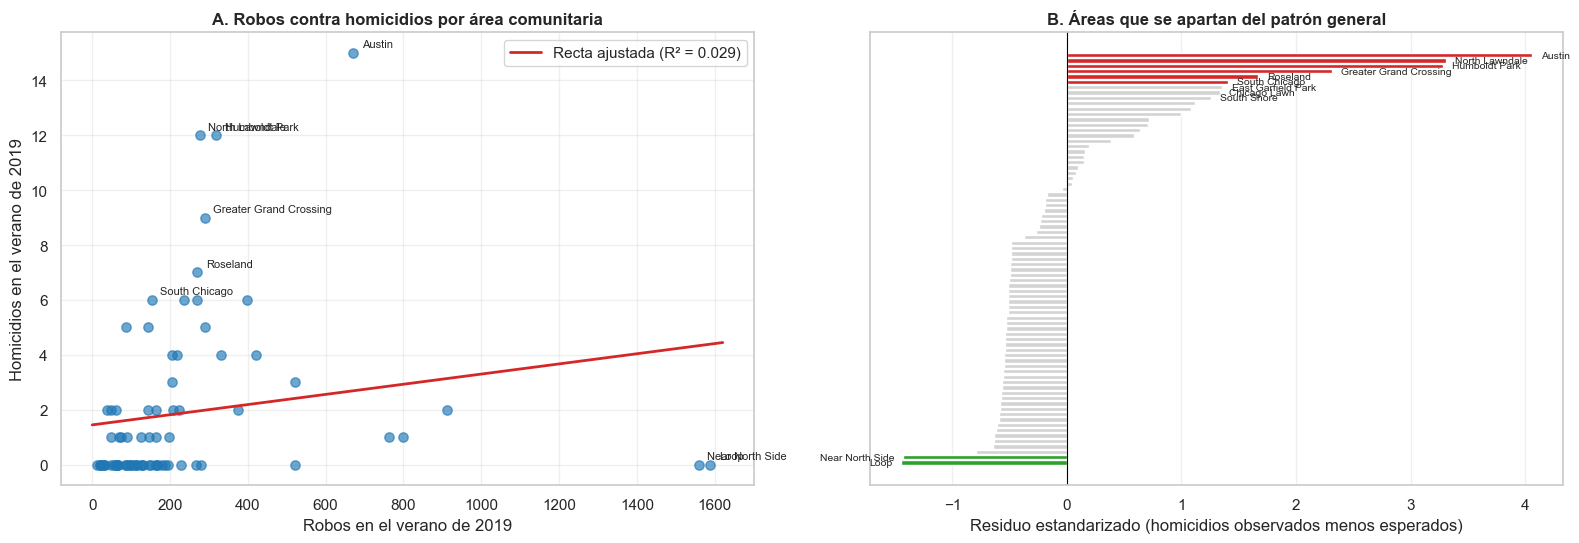

AREAS CON MAS HOMICIDIOS DE LOS QUE PREDICE SU NIVEL DE ROBOS
             community  robo  homicidio  predicho  residuo_std
                AUSTIN   671         15      2.69         4.06
        NORTH LAWNDALE   277         12      1.96         3.31
         HUMBOLDT PARK   319         12      2.04         3.28
GREATER GRAND CROSSING   289          9      1.98         2.31
              ROSELAND   270          7      1.95         1.67
         SOUTH CHICAGO   153          6      1.73         1.41

AREAS CON MENOS HOMICIDIOS DE LOS ESPERADOS
      community  robo  homicidio  predicho  residuo_std
           LOOP  1589          0      4.39        -1.45
NEAR NORTH SIDE  1559          0      4.33        -1.43
   LOGAN SQUARE   520          0      2.41        -0.79
     WEST RIDGE   280          0      1.97        -0.65
         UPTOWN   266          0      1.94        -0.64
      WEST TOWN   798          1      2.92        -0.63


In [13]:
# ==============================================================================
#      DISPERSION CON RECTA DE REGRESION Y AREAS ATIPICAS
# ==============================================================================
tabla["predicho"] = intercepto + pendiente * tabla["robo"]
tabla["residuo"] = tabla["homicidio"] - tabla["predicho"]
tabla["residuo_std"] = tabla["residuo"] / tabla["residuo"].std()

fig, axes = plt.subplots(1, 2, figsize=(16, 5.6))

# Panel A: dispersion con recta
ax = axes[0]
ax.scatter(tabla["robo"], tabla["homicidio"], s=45, alpha=0.65, color="tab:blue")
x_line = np.linspace(0, tabla["robo"].max() * 1.02, 100)
ax.plot(x_line, intercepto + pendiente * x_line, color="tab:red", lw=2,
        label=f"Recta ajustada (R² = {r_val**2:.3f})")
for _, r in tabla[tabla["residuo_std"].abs() > 1.4].iterrows():
    ax.annotate(r["community"].title(), (r["robo"], r["homicidio"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_xlabel("Robos en el verano de 2019")
ax.set_ylabel("Homicidios en el verano de 2019")
ax.set_title("A. Robos contra homicidios por área comunitaria",
             fontsize=12, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)

# Panel B: residuos estandarizados
ax = axes[1]
orden_res = tabla.sort_values("residuo_std")
colores = ["tab:red" if v > 1.4 else ("tab:green" if v < -1.2 else "lightgray")
           for v in orden_res["residuo_std"]]
ax.barh(range(len(orden_res)), orden_res["residuo_std"], color=colores)
ax.axvline(0, color="black", lw=0.8)
for i, (_, r) in enumerate(orden_res.iterrows()):
    if abs(r["residuo_std"]) > 1.2:
        ax.text(r["residuo_std"] + (0.08 if r["residuo_std"] > 0 else -0.08), i,
                r["community"].title(), va="center", fontsize=7.5,
                ha="left" if r["residuo_std"] > 0 else "right")
ax.set_yticks([])
ax.set_xlabel("Residuo estandarizado (homicidios observados menos esperados)")
ax.set_title("B. Áreas que se apartan del patrón general",
             fontsize=12, fontweight="bold")
ax.grid(alpha=0.3, axis="x")

plt.tight_layout()
plt.show()

print("AREAS CON MAS HOMICIDIOS DE LOS QUE PREDICE SU NIVEL DE ROBOS")
print(tabla.nlargest(6, "residuo")[["community", "robo", "homicidio", "predicho", "residuo_std"]]
      .to_string(index=False, float_format=lambda v: f"{v:.2f}"))
print()
print("AREAS CON MENOS HOMICIDIOS DE LOS ESPERADOS")
print(tabla.nsmallest(6, "residuo")[["community", "robo", "homicidio", "predicho", "residuo_std"]]
      .to_string(index=False, float_format=lambda v: f"{v:.2f}"))

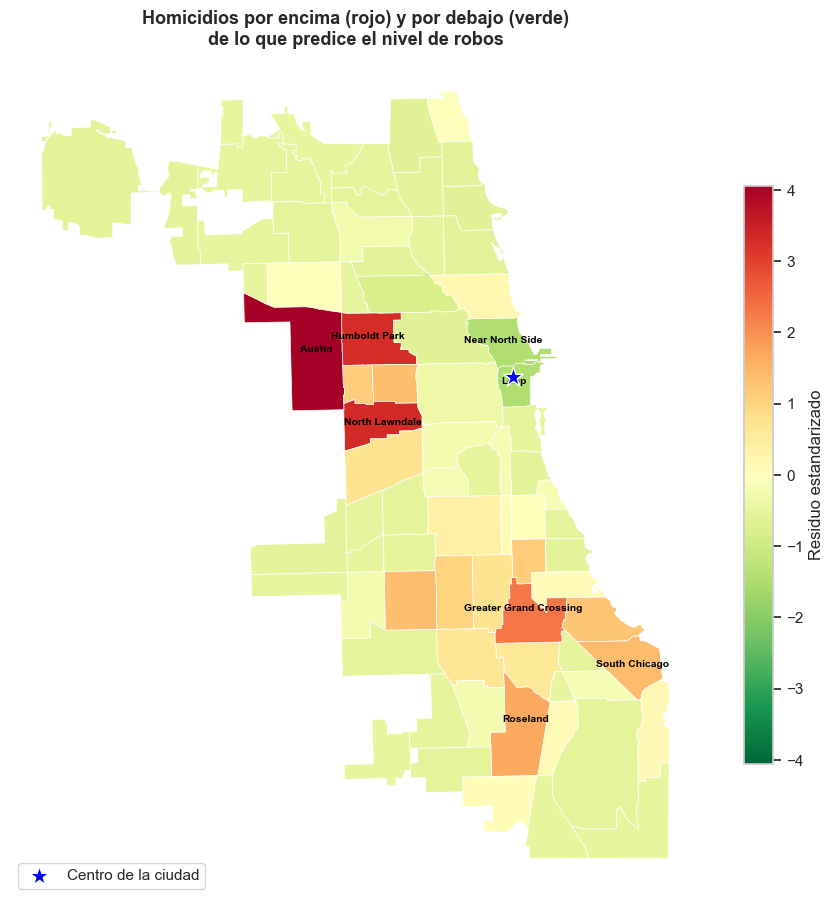

In [14]:
# ==============================================================================
#        DONDE ESTAN LAS AREAS ATIPICAS
# ==============================================================================
areas_res = areas.merge(tabla[["nro_area_comunitaria", "residuo_std", "robo", "homicidio"]],
                        left_on="area_num", right_on="nro_area_comunitaria", how="left")

fig, ax = plt.subplots(figsize=(9, 10))
lim = np.nanmax(np.abs(areas_res["residuo_std"]))
areas_res.plot(column="residuo_std", cmap="RdYlGn_r", vmin=-lim, vmax=lim,
               legend=True, edgecolor="white", linewidth=0.5, ax=ax,
               legend_kwds={"label": "Residuo estandarizado", "shrink": 0.6})
for _, r in areas_res[areas_res["residuo_std"].abs() > 1.4].iterrows():
    c = r.geometry.representative_point()
    ax.annotate(r["community"].title(), (c.x, c.y), ha="center", fontsize=7.5,
                color="black", fontweight="bold")
ax.scatter([CENTRO_LON], [CENTRO_LAT], marker="*", s=220, color="blue",
           edgecolor="white", zorder=5, label="Centro de la ciudad")
ax.set_title("Homicidios por encima (rojo) y por debajo (verde)\nde lo que predice el nivel de robos",
             fontsize=13, fontweight="bold")
ax.legend(loc="lower left")
ax.set_axis_off()
plt.tight_layout()
plt.show()

**La relación existe, pero es débil y depende por completo de cómo se la mida.**

La correlación de **Pearson es de +0,171 y no alcanza significancia estadística** (p = 0,137). Los robos explican apenas el **2,9%** de la varianza de los homicidios entre áreas. La recta ajustada implica un homicidio adicional por cada 540 robos adicionales.

La correlación de **Spearman, en cambio, es de +0,464 y sí es significativa** (p = 0,00002). Esa discrepancia es informativa: existe una asociación **de orden**, las áreas con más robos tienden a tener más homicidios, pero no es una relación lineal.

**La causa de la discrepancia son dos áreas del centro.** El Loop y Near North Side tienen los dos mayores volúmenes de robo de la ciudad, más de 1.500 cada una, y cero homicidios. Al excluirlas, el Pearson sube de +0,171 a **+0,397** y el R² pasa del 2,9% al 15,8%. Es decir, **el 87% de la relación lineal que uno podría reportar depende de si se incluyen o no dos barrios**. Un resultado así no sirve como base para una regla de patrullaje.

**Las áreas que se apartan del patrón lo hacen de forma asimétrica.** Austin tiene 15 homicidios cuando su nivel de robos predice 2,7, un residuo de **+4,1 desviaciones**. North Lawndale y Humboldt Park le siguen con +3,3 cada una. Del otro lado, el mayor déficit es el del Loop con -1,45 desviaciones.

Esa asimetría no es casual: los homicidios no pueden bajar de cero, así que un área no puede tener "muchos menos de los esperados" cuando lo esperado son cuatro. **Los excesos son grandes y los déficits son pequeños por construcción**, lo que a su vez indica que el modelo lineal es inadecuado para este tipo de conteo.

En el mapa, las áreas con exceso de homicidios forman un patrón claro: un corredor en el oeste (Austin, Humboldt Park, North Lawndale, East Garfield Park) y otro en el sur (Greater Grand Crossing, Roseland, South Chicago). Las de déficit están todas en el centro y el norte, sobre la costa del lago.

## 2.1 ¿Qué tan sólida es la evidencia de cada delito?

Esta es la pregunta que más pesa en la decisión, y admite una respuesta cuantitativa. Un conteo de eventos raros se comporta aproximadamente como una variable de Poisson, cuyo error estándar es la raíz del propio conteo. El error relativo es entonces $1/\sqrt{n}$: con 100 casos se conoce el nivel con un margen del 10%, con 4 casos el margen es del 50%.

In [15]:
# ==============================================================================
#     PRECISION DE LOS CONTEOS POR AREA SEGUN EL TIPO DE DELITO
# ==============================================================================
print("=" * 78)
print("ERROR RELATIVO DE LOS CONTEOS (aproximacion de Poisson)")
print("=" * 78)
for etiqueta in ["robo", "homicidio"]:
    v = tabla[etiqueta]
    mediana = v.median()
    maximo = v.max()
    print()
    print(etiqueta.upper())
    print(f"  casos por area: mediana {mediana:.0f} | media {v.mean():.1f} | maximo {maximo:.0f}")
    if mediana > 0:
        print(f"  area mediana ({mediana:.0f} casos)   -> error relativo {100/np.sqrt(mediana):.0f}%")
    else:
        print(f"  area mediana ({mediana:.0f} casos)   -> el conteo no permite estimar nada")
    print(f"  area con mas casos ({maximo:.0f}) -> error relativo {100/np.sqrt(maximo):.0f}%")
    print(f"  areas con 0 casos          : {int((v == 0).sum())} de 77")
    print(f"  areas con menos de 5 casos : {int((v < 5).sum())} de 77")
print("=" * 78)

ERROR RELATIVO DE LOS CONTEOS (aproximacion de Poisson)

ROBO
  casos por area: mediana 147 | media 228.6 | maximo 1589
  area mediana (147 casos)   -> error relativo 8%
  area con mas casos (1589) -> error relativo 3%
  areas con 0 casos          : 0 de 77
  areas con menos de 5 casos : 0 de 77

HOMICIDIO
  casos por area: mediana 0 | media 1.9 | maximo 15
  area mediana (0 casos)   -> el conteo no permite estimar nada
  area con mas casos (15) -> error relativo 26%
  areas con 0 casos          : 40 de 77
  areas con menos de 5 casos : 65 de 77


In [16]:
# ==============================================================================
#   ¿SOBREVIVIRIA EL RANKING A OTRO VERANO CON LAS MISMAS TASAS?
# ==============================================================================
# Simulamos veranos alternativos: mismo riesgo subyacente, distinto azar
rng = np.random.RandomState(RANDOM_STATE)
N_SIM = 1000

def estabilidad_ranking(columna, k):
    real = set(tabla.nlargest(k, columna)["community"])
    coincidencias = []
    for _ in range(N_SIM):
        simulado = pd.Series(rng.poisson(tabla[columna].values), index=tabla["community"])
        coincidencias.append(len(real & set(simulado.nlargest(k).index)))
    return np.mean(coincidencias), np.percentile(coincidencias, [5, 95])

print("=" * 82)
print(f"ESTABILIDAD DEL RANKING EN {N_SIM} VERANOS SIMULADOS CON EL MISMO RIESGO")
print("=" * 82)
print(f"{'delito':12} {'ranking':10} {'coinciden en promedio':>24} {'rango 5-95%':>16}")
for columna in ["robo", "homicidio"]:
    for k in [5, 10]:
        media, rango = estabilidad_ranking(columna, k)
        print(f"{columna:12} top {k:<6} {media:>18.1f} de {k:<3} "
              f"{f'[{rango[0]:.0f}, {rango[1]:.0f}]':>16}")
print("=" * 82)
print("Un ranking estable deberia recuperar casi todos sus puestos en un verano equivalente.")

ESTABILIDAD DEL RANKING EN 1000 VERANOS SIMULADOS CON EL MISMO RIESGO
delito       ranking       coinciden en promedio      rango 5-95%


robo         top 5                     5.0 de 5             [5, 5]


robo         top 10                    9.8 de 10           [9, 10]


homicidio    top 5                     3.8 de 5             [3, 5]


homicidio    top 10                    7.6 de 10            [6, 9]
Un ranking estable deberia recuperar casi todos sus puestos en un verano equivalente.


**La evidencia de robos es sólida y la de homicidios no lo es.**

Para el **robo**, el área mediana registra 147 casos, lo que implica un error relativo del **8%**, y el área con más casos llega al 3%. Todas las áreas tienen datos suficientes.

Para el **homicidio**, el área mediana registra **cero casos**. Ni siquiera el área con más homicidios de toda la ciudad, Austin con 15, baja de un **26% de error relativo**. Y **65 de las 77 áreas tienen menos de cinco homicidios** en todo el verano, un nivel en el que el conteo observado no distingue de forma confiable entre un área peligrosa y una tranquila.

**La simulación lo confirma de manera directa.** Si repitiéramos el verano de 2019 con exactamente el mismo riesgo subyacente en cada área, y solo cambiara el azar:

- El **top 5 de robos se recuperaría completo**, 5,0 de 5 en promedio, y el top 10 conservaría 9,8 de 10. El ranking es reproducible.
- El **top 5 de homicidios conservaría solo 3,8 de 5**, y el top 10 apenas 7,6 de 10. Más de un puesto de cada cinco cambiaría por azar, sin que nada haya cambiado en la ciudad.

Esto no dice que los homicidios ocurran al azar ni que Austin no sea peligrosa. Dice que **con tres meses de datos el conteo por área no tiene resolución suficiente para ordenar prioridades de homicidio**, y que cualquier procedimiento construido sobre esos conteos hereda esa fragilidad. Es una limitación del volumen de evidencia, no del método.

## 2.2 ¿Qué implicaría agregarlos en una sola medida?

In [17]:
# ==============================================================================
#     UN RANKING UNICO, ¿DE QUE SERIA REALMENTE EL RANKING?
# ==============================================================================
rho_total_robo = stats.spearmanr(tabla["total"], tabla["robo"]).statistic
rho_total_homi = stats.spearmanr(tabla["total"], tabla["homicidio"]).statistic

top10_total = set(tabla.nlargest(10, "total")["community"])
top10_robo = set(tabla.nlargest(10, "robo")["community"])
top10_homi = set(tabla.nlargest(10, "homicidio")["community"])

print("=" * 78)
print("SI SE SUMARAN LOS DOS DELITOS EN UN SOLO INDICADOR")
print("=" * 78)
print(f"Correlacion de Spearman entre el total y los robos      : {rho_total_robo:+.4f}")
print(f"Correlacion de Spearman entre el total y los homicidios : {rho_total_homi:+.4f}")
print()
print(f"Top 10 del total que coincide con el top 10 de robos      : "
      f"{len(top10_total & top10_robo)}/10")
print(f"Top 10 del total que coincide con el top 10 de homicidios : "
      f"{len(top10_total & top10_homi)}/10")
print()
peso_homi = tabla["homicidio"].sum() / tabla["total"].sum() * 100
print(f"Peso del homicidio en el indicador agregado: {peso_homi:.2f}% de los casos")
print("=" * 78)

SI SE SUMARAN LOS DOS DELITOS EN UN SOLO INDICADOR
Correlacion de Spearman entre el total y los robos      : +0.9997
Correlacion de Spearman entre el total y los homicidios : +0.4721

Top 10 del total que coincide con el top 10 de robos      : 10/10
Top 10 del total que coincide con el top 10 de homicidios : 2/10

Peso del homicidio en el indicador agregado: 0.81% de los casos


**Sumarlos equivale a usar el ranking de robos y llamarlo de otra manera.**

La correlación de Spearman entre el total y los robos es de **+0,9997**, prácticamente perfecta. Entre el total y los homicidios es de **+0,472**. El top 10 del total coincide con el de robos en **10 de 10** y con el de homicidios en solo 2 de 10.

La aritmética lo explica sin misterio: los homicidios son el **0,81%** de los casos. En una suma simple, quince homicidios en Austin pesan lo mismo que quince robos de celular en el Loop, y el resultado lo determina casi por completo el delito más frecuente.

**Tres consecuencias para la decisión del cliente.**

**No se pueden agregar sin ponderar.** Si la policía quisiera un indicador único tendría que decidir explícitamente cuánto vale un homicidio en relación con un robo. Esa es una decisión de política pública, no estadística, y debe tomarla el cliente y no el analista. Cualquier ponderación implícita, como la que produce una suma simple, es una decisión tomada sin declararla.

**Conviene tratarlos por separado.** De aquí en adelante estimamos y comparamos los procedimientos para cada delito, no para el agregado. El Paso 1 ya mostró que se concentran en lugares distintos y este paso agrega que la asociación entre ellos es débil.

**Y hay una asimetría de evidencia que no se puede ignorar.** El delito que más importa para la seguridad ciudadana, el homicidio, es justamente el que tiene menos datos para orientar el patrullaje. Cualquier recomendación tiene que decir esto de frente en vez de esconderlo detrás de un mapa agregado.

### Cierre del Paso 2

1. **La relación lineal entre robos y homicidios es débil y no significativa**: Pearson de +0,171 con p = 0,137, y los robos explican solo el 2,9% de la varianza de los homicidios.
2. **La relación de orden sí es significativa**: Spearman de +0,464 con p = 0,00002. Hay asociación, pero no lineal.
3. **El resultado depende de dos barrios.** Excluyendo el Loop y Near North Side, que tienen más de 1.500 robos y cero homicidios, el Pearson sube de +0,171 a +0,397 y el R² del 2,9% al 15,8%.
4. **Las áreas atípicas forman un patrón geográfico claro**: exceso de homicidios en un corredor oeste (Austin con +4,1 desviaciones, North Lawndale y Humboldt Park con +3,3) y otro sur; déficit en el centro y el norte junto al lago.
5. **La asimetría de los residuos revela que el modelo lineal es inadecuado** para conteos acotados en cero: los excesos llegan a +4,1 desviaciones y los déficits no pasan de -1,5.
6. **La evidencia de robos es sólida**: el área mediana tiene 147 casos, con un error relativo del 8%.
7. **La evidencia de homicidios no lo es**: el área mediana tiene cero casos, 65 de 77 áreas tienen menos de cinco, y ni siquiera Austin, con 15, baja del 26% de error relativo.
8. **Simulando 1.000 veranos con el mismo riesgo, el top 5 de robos se recupera completo (5,0 de 5) y el de homicidios conserva solo 3,8 de 5.** En el top 10 la diferencia se mantiene: 9,8 de 10 para robos contra 7,6 de 10 para homicidios. El ranking de homicidios no es reproducible ni contra sí mismo.
9. **Agregar los dos delitos en una suma simple produce el ranking de robos**, con Spearman de +0,9997, porque los homicidios son el 0,81% de los casos. Ponderarlos es una decisión de política que corresponde al cliente.

# Paso 3. Visualizando los datos

El ranking por conteo del Paso 1 tiene un problema evidente: las áreas comunitarias difieren hasta 22 veces en superficie, así que un área grande acumula más delitos por el solo hecho de ser grande.

Este paso construye el mapa de conteos y el de conteos normalizados por superficie, y examina cuánto cambia la decisión de patrullaje al pasar de uno al otro.

## 3.1 Elección del sistema de coordenadas

Para calcular superficies hay que trabajar en un sistema **proyectado**, es decir con unidades métricas. Los datos vienen en WGS84 (EPSG:4326), cuyas unidades son grados, y un grado de longitud mide distinto según la latitud. Calcular áreas ahí daría un número sin sentido físico.

Elegimos **EPSG:26971, NAD83 / Illinois East**, que es la proyección oficial para esta zona de Illinois y está en metros. Verificamos la decisión de dos maneras.

In [18]:
# ==============================================================================
#      ¿POR QUE IMPORTA EL CRS PARA CALCULAR SUPERFICIES?
# ==============================================================================
print("=" * 78)
print("SUPERFICIE TOTAL DE CHICAGO SEGUN EL SISTEMA DE COORDENADAS")
print("=" * 78)
for crs, nombre, unidad in [
        ("EPSG:26971", "NAD83 / Illinois East", "metros"),
        ("EPSG:6933", "Cilindrica de areas iguales", "metros"),
        ("EPSG:3857", "Pseudo-Mercator (mapas web)", "metros"),
]:
    total = areas.to_crs(crs).geometry.area.sum() / 1e6
    print(f"  {nombre:32} {total:8.1f} km2   ({unidad})")
print("=" * 78)
print("La superficie real de Chicago es de unos 590 km2 segun fuentes oficiales.")
print("Pseudo-Mercator, el CRS de los mapas web, la sobreestima en cerca del 80%")
print("porque distorsiona las areas a medida que uno se aleja del ecuador.")

SUPERFICIE TOTAL DE CHICAGO SEGUN EL SISTEMA DE COORDENADAS
  NAD83 / Illinois East               598.1 km2   (metros)
  Cilindrica de areas iguales         598.1 km2   (metros)
  Pseudo-Mercator (mapas web)        1078.4 km2   (metros)
La superficie real de Chicago es de unos 590 km2 segun fuentes oficiales.
Pseudo-Mercator, el CRS de los mapas web, la sobreestima en cerca del 80%
porque distorsiona las areas a medida que uno se aleja del ecuador.


In [19]:
# ==============================================================================
#    CONTRASTE CONTRA LA COLUMNA shape_area QUE TRAE EL SHAPEFILE
# ==============================================================================
areas_m = areas.to_crs(CRS_METRICO).copy()
areas_m["km2"] = areas_m.geometry.area / 1e6

# shape_area viene en pies cuadrados (Illinois State Plane en pies)
PIE2_A_M2 = 0.09290304
areas_m["km2_shapefile"] = areas_m["shape_area"] * PIE2_A_M2 / 1e6

print("=" * 78)
print("VERIFICACION CONTRA LA COLUMNA DEL SHAPEFILE")
print("=" * 78)
print(f"Superficie total calculada por nosotros : {areas_m.km2.sum():.1f} km2")
print(f"Superficie total segun shape_area        : {areas_m.km2_shapefile.sum():.1f} km2")
print(f"Correlacion entre ambas                  : "
      f"{stats.pearsonr(areas_m.km2, areas_m.km2_shapefile).statistic:.6f}")
print(f"Razon mediana shapefile / calculada      : "
      f"{(areas_m.km2_shapefile / areas_m.km2).median():.4f}")
print("=" * 78)
print("Coinciden exactamente, lo que confirma la eleccion de EPSG:26971.")

VERIFICACION CONTRA LA COLUMNA DEL SHAPEFILE
Superficie total calculada por nosotros : 598.1 km2
Superficie total segun shape_area        : 598.1 km2
Correlacion entre ambas                  : 1.000000
Razon mediana shapefile / calculada      : 1.0000
Coinciden exactamente, lo que confirma la eleccion de EPSG:26971.


**La elección del CRS no es un tecnicismo.** Si hubiéramos calculado las superficies en Pseudo-Mercator, el sistema que usan casi todos los mapas web y al que es fácil llegar por descuido, habríamos obtenido **1.078 km² en vez de 598**, una sobreestimación del 80%. Como la distorsión de Mercator crece con la latitud, ni siquiera sería un error uniforme: afectaría más a las áreas del norte que a las del sur, deformando el ranking de densidades.

La verificación contra `shape_area`, que el shapefile trae en pies cuadrados, da una coincidencia exacta con correlación de 1,000000. La superficie calculada es confiable.

## 3.2 Conteo contra densidad

In [20]:
# ==============================================================================
#           CONTEO Y DENSIDAD POR AREA COMUNITARIA
# ==============================================================================
tabla = tabla.merge(areas_m[["area_num", "km2"]], left_on="nro_area_comunitaria",
                    right_on="area_num", how="left", suffixes=("", "_y"))
for c in ["robo", "homicidio", "total"]:
    tabla[c + "_km2"] = tabla[c] / tabla["km2"]

print("=" * 88)
print("¿CAMBIAN LAS PRIORIDADES AL NORMALIZAR POR SUPERFICIE?")
print("=" * 88)
for c in ["robo", "homicidio"]:
    rho = stats.spearmanr(tabla[c], tabla[c + "_km2"]).statistic
    top_conteo = tabla.nlargest(10, c)["community"]
    top_dens = tabla.nlargest(10, c + "_km2")["community"]
    print(f"\n{c.upper()}")
    print(f"  Spearman entre conteo y densidad : {rho:+.3f}")
    print(f"  Coincidencia en el top 10        : {len(set(top_conteo) & set(top_dens))}/10")
    print(f"  Top 5 por conteo   : {', '.join(t.title() for t in top_conteo.head(5))}")
    print(f"  Top 5 por densidad : {', '.join(t.title() for t in top_dens.head(5))}")
print("=" * 88)

¿CAMBIAN LAS PRIORIDADES AL NORMALIZAR POR SUPERFICIE?

ROBO
  Spearman entre conteo y densidad : +0.799
  Coincidencia en el top 10        : 9/10
  Top 5 por conteo   : Loop, Near North Side, Near West Side, West Town, Lake View
  Top 5 por densidad : Loop, Near North Side, Lake View, Rogers Park, West Town

HOMICIDIO
  Spearman entre conteo y densidad : +0.973
  Coincidencia en el top 10        : 7/10
  Top 5 por conteo   : Austin, Humboldt Park, North Lawndale, Greater Grand Crossing, Roseland
  Top 5 por densidad : West Garfield Park, North Lawndale, Humboldt Park, Washington Park, East Garfield Park


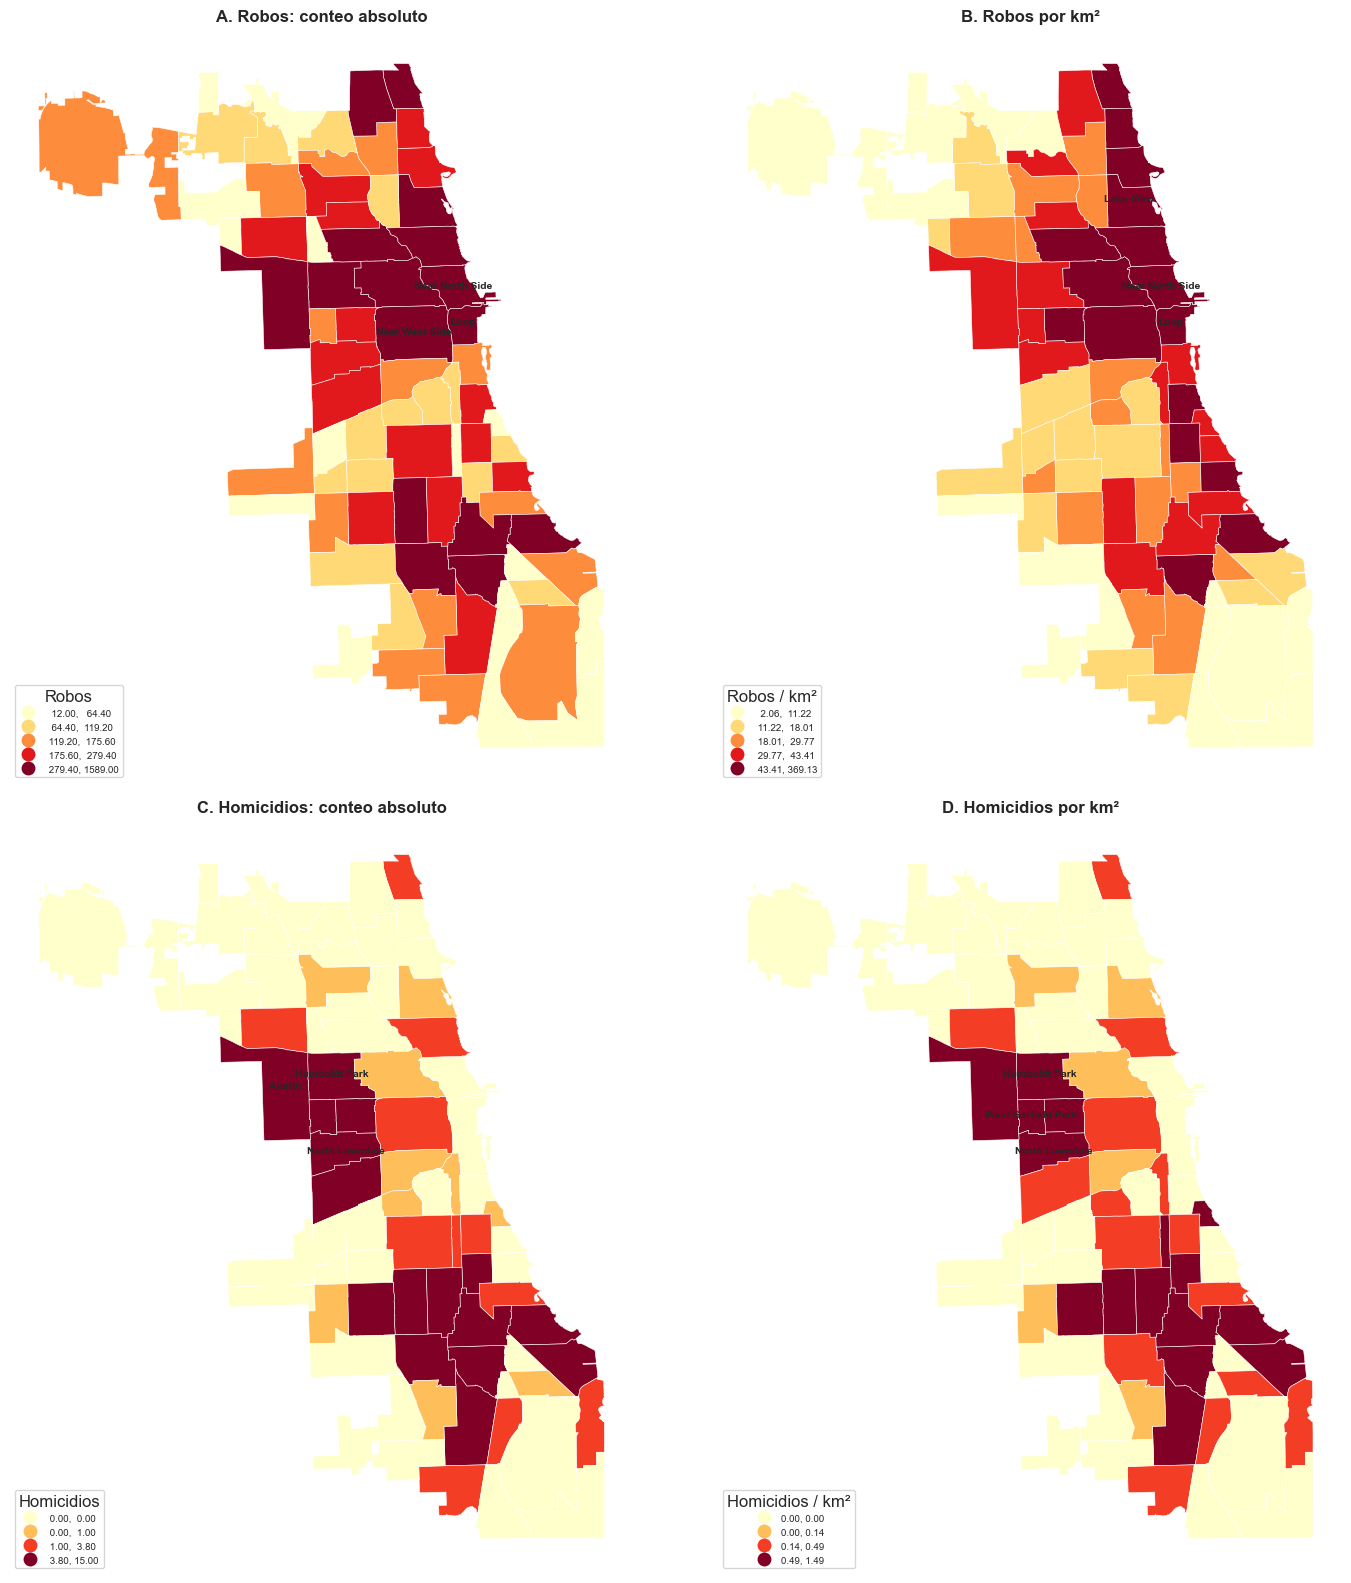

In [21]:
# ==============================================================================
#        LOS DOS MAPAS, LADO A LADO
# ==============================================================================
areas_mapa3 = areas_m.merge(
    tabla[["nro_area_comunitaria", "robo", "homicidio", "robo_km2", "homicidio_km2"]],
    left_on="area_num", right_on="nro_area_comunitaria", how="left")

fig, axes = plt.subplots(2, 2, figsize=(15, 16))
config = [
    ("robo", "A. Robos: conteo absoluto", "Robos"),
    ("robo_km2", "B. Robos por km²", "Robos / km²"),
    ("homicidio", "C. Homicidios: conteo absoluto", "Homicidios"),
    ("homicidio_km2", "D. Homicidios por km²", "Homicidios / km²"),
]
for ax, (col, titulo, etiqueta) in zip(axes.ravel(), config):
    areas_mapa3.plot(column=col, cmap="YlOrRd", legend=True, edgecolor="white",
                     linewidth=0.4, ax=ax, scheme="quantiles", k=5,
                     legend_kwds={"loc": "lower left", "fontsize": 7, "title": etiqueta})
    # nombrar las tres primeras de cada criterio
    for _, r in areas_mapa3.nlargest(3, col).iterrows():
        c = r.geometry.representative_point()
        ax.annotate(r["community"].title(), (c.x, c.y), ha="center",
                    fontsize=7.5, fontweight="bold")
    ax.set_title(titulo, fontsize=12, fontweight="bold")
    ax.set_axis_off()

plt.tight_layout()
plt.show()

In [22]:
# ==============================================================================
#      ¿QUE AREAS SE MUEVEN MAS AL NORMALIZAR?
# ==============================================================================
tabla["rank_conteo"] = tabla["robo"].rank(ascending=False)
tabla["rank_densidad"] = tabla["robo_km2"].rank(ascending=False)
tabla["salto"] = tabla["rank_conteo"] - tabla["rank_densidad"]

cols = ["community", "robo", "km2", "rank_conteo", "rank_densidad", "salto"]
print("=" * 88)
print("AREAS QUE MAS SUBEN AL NORMALIZAR (son pequenas y densas)")
print("=" * 88)
print(tabla.nlargest(5, "salto")[cols].to_string(index=False, float_format=lambda v: f"{v:.1f}"))
print()
print("=" * 88)
print("AREAS QUE MAS BAJAN AL NORMALIZAR (son grandes y poco densas)")
print("=" * 88)
print(tabla.nsmallest(5, "salto")[cols].to_string(index=False, float_format=lambda v: f"{v:.1f}"))
print("=" * 88)

# El caso de Austin en homicidios
austin = tabla[tabla["community"] == "AUSTIN"].iloc[0]
print()
print(f"Caso AUSTIN (homicidios): {int(austin.homicidio)} casos en {austin.km2:.1f} km2 "
      f"= {austin.homicidio_km2:.2f} por km2")
print(f"  puesto por conteo  : {int(tabla['homicidio'].rank(ascending=False)[austin.name])}")
print(f"  puesto por densidad: {int(tabla['homicidio_km2'].rank(ascending=False)[austin.name])}")

AREAS QUE MAS SUBEN AL NORMALIZAR (son pequenas y densas)
         community  robo  km2  rank_conteo  rank_densidad  salto
           OAKLAND    47  1.6         68.5           31.0   37.5
       FULLER PARK    48  1.9         67.0           34.0   33.0
     ARMOUR SQUARE    88  2.6         54.5           23.0   31.5
           KENWOOD   116  2.7         47.0           17.0   30.0
WEST GARFIELD PARK   142  3.4         41.5           18.0   23.5

AREAS QUE MAS BAJAN AL NORMALIZAR (son grandes y poco densas)
     community  robo  km2  rank_conteo  rank_densidad  salto
         OHARE   163 34.5         36.0           72.0  -36.0
 SOUTH DEERING   128 28.2         44.0           73.0  -29.0
      NEW CITY   206 12.5         26.5           51.0  -24.5
SOUTH LAWNDALE   206 11.9         26.5           49.0  -22.5
      ROSELAND   270 12.5         18.5           40.0  -21.5

Caso AUSTIN (homicidios): 15 casos en 18.5 km2 = 0.81 por km2
  puesto por conteo  : 1
  puesto por densidad: 8


**Normalizar cambia menos de lo que uno esperaría, pero cambia lo que importa.**

La correlación de Spearman entre conteo y densidad es de **+0,799 para robos** y **+0,973 para homicidios**, y el top 10 coincide en 9 y 7 casos de 10 respectivamente. En términos gruesos, las mismas áreas siguen apareciendo.

Lo que cambia es la cima de cada lista, que es justamente lo que define el patrullaje.

**En robos**, el Loop y Near North Side siguen primeros por ambos criterios: son pequeños y concentran muchísimo. Pero entra Rogers Park, un área compacta del extremo norte, y salen áreas grandes del ranking.

**En homicidios el cambio es más elocuente.** Austin encabeza el conteo con 15 casos, pero es la tercera área más grande de la ciudad con 18,5 km². Al dividir por superficie, **cae del primer puesto al octavo** y el liderazgo pasa a West Garfield Park, que tiene menos homicidios en total pero los concentra en 3,4 km². Su densidad es de 0,81 homicidios por km², frente a los 15 casos absolutos que la ponían primera.

**Los movimientos extremos confirman el mecanismo.** O'Hare baja 36 puestos: es el aeropuerto, 34,5 km² con muy poco delito por unidad de superficie. South Deering baja 29. En sentido contrario, Oakland sube 37 puestos y Fuller Park 33: son las dos áreas más pequeñas de la ciudad, con 1,6 y 1,9 km².

**Qué significa normalizar por superficie.** Pasar de "dónde ocurren más delitos" a "dónde es más probable que un patrullero se cruce con uno". Para una decisión de patrullaje la segunda pregunta es la pertinente, porque el recurso que se asigna es tiempo de recorrido sobre un territorio, y recorrer 34 km² cuesta mucho más que recorrer 1,6.

## 3.3 ¿Qué otros denominadores tendrían sentido?

La superficie es el denominador más simple, pero no el único ni necesariamente el mejor. Cada uno responde una pregunta distinta:

- **Por superficie (km²)**: dónde es más denso el delito por unidad de territorio. Es el que mejor se alinea con el costo de patrullar, que es recorrer calles.
- **Por población residente**: dónde es mayor el riesgo para quien vive ahí. Cambia mucho el resultado en zonas como el Loop, que tiene poquísimos residentes y una enorme población flotante.
- **Por población flotante o afluencia diaria**: dónde es mayor el riesgo por persona expuesta. Es el denominador correcto para el robo en zonas comerciales, y es el que explicaría por qué el Loop lidera en robos sin ser residencialmente denso.
- **Por kilómetros de vía o por número de intersecciones**: dónde es mayor el delito por unidad de calle patrullable. Es el más cercano a la logística real de una patrulla.
- **Por establecimientos comerciales**: relevante para robos, y es lo que el Paso 6 explora con datos de OpenStreetMap.

**Ninguno de estos denominadores está disponible en las bases de este taller**, lo cual es en sí mismo un resultado: con los datos entregados solo se puede normalizar por superficie, y eso limita lo que el procedimiento puede afirmar. En particular, **el Loop lidera los robos en términos absolutos y por km², pero casi no tiene residentes**: su tasa por habitante sería altísima y su tasa por persona presente durante el día, mucho menor.

## 3.4 ¿Cuánto depende el resultado de las unidades territoriales?

Las áreas comunitarias son una división administrativa heredada, no una unidad diseñada para patrullar. Conviene medir cuánto de lo que encontramos depende de esa elección. Repetimos el ejercicio sobre grillas regulares de 1 y 2 kilómetros de lado, que no tienen ningún significado administrativo.

In [23]:
# ==============================================================================
#     EL MISMO DELITO, CONTADO SOBRE OTRAS UNIDADES TERRITORIALES
# ==============================================================================
from shapely.geometry import box

puntos_m = gpd.GeoDataFrame(delitos.copy(),
                            geometry=gpd.points_from_xy(delitos.lon, delitos.lat),
                            crs=CRS_GEO).to_crs(CRS_METRICO)

def grilla_regular(lado_m):
    minx, miny, maxx, maxy = areas_m.total_bounds
    celdas = [box(x, y, x + lado_m, y + lado_m)
              for x in np.arange(minx, maxx, lado_m)
              for y in np.arange(miny, maxy, lado_m)]
    g = gpd.GeoDataFrame(geometry=celdas, crs=CRS_METRICO)
    # conservar solo las celdas que tocan la ciudad
    dentro = gpd.sjoin(g, areas_m[["geometry"]], predicate="intersects")
    return g.loc[sorted(set(dentro.index))].reset_index(drop=True)

SUP_CHICAGO = areas_m["km2"].sum()
filas_unidad = []

# Unidad administrativa: las 77 areas comunitarias
top10_areas = tabla.nlargest(10, "robo")
filas_unidad.append({
    "unidad": "77 áreas comunitarias",
    "n_unidades": len(tabla),
    "sup_media_km2": SUP_CHICAGO / len(tabla),
    "robos_top10_pct": top10_areas["robo"].sum() / tabla["robo"].sum() * 100,
    "sup_top10_km2": top10_areas["km2"].sum(),
})

# Grillas regulares
for lado in [2000, 1000]:
    g = grilla_regular(lado)
    j = gpd.sjoin(puntos_m[puntos_m["tipo_crimen"] == "robo"], g, predicate="within")
    g["robos"] = g.index.map(j.groupby("index_right").size()).fillna(0)
    top10 = g.nlargest(10, "robos")
    filas_unidad.append({
        "unidad": f"grilla de {lado//1000} km",
        "n_unidades": len(g),
        "sup_media_km2": (lado / 1000) ** 2,
        "robos_top10_pct": top10["robos"].sum() / g["robos"].sum() * 100,
        "sup_top10_km2": 10 * (lado / 1000) ** 2,
    })

comp_unidad = pd.DataFrame(filas_unidad)
comp_unidad["sup_top10_pct"] = comp_unidad["sup_top10_km2"] / SUP_CHICAGO * 100
comp_unidad["concentracion"] = comp_unidad["robos_top10_pct"] / comp_unidad["sup_top10_pct"]

print("=" * 100)
print("LAS 10 UNIDADES CON MAS ROBOS, SEGUN COMO SE DIVIDA LA CIUDAD")
print("=" * 100)
print(comp_unidad.to_string(index=False, float_format=lambda v: f"{v:.1f}"))
print("=" * 100)
print("robos_top10_pct  = % de robos que caen en las 10 unidades con mas robos")
print("sup_top10_pct    = % de la ciudad que ocupan esas 10 unidades")
print("concentracion    = cuantas veces mas denso es el top 10 que el promedio de la ciudad")

LAS 10 UNIDADES CON MAS ROBOS, SEGUN COMO SE DIVIDA LA CIUDAD
               unidad  n_unidades  sup_media_km2  robos_top10_pct  sup_top10_km2  sup_top10_pct  concentracion
77 áreas comunitarias          77            7.8             46.3           97.4           16.3            2.8
       grilla de 2 km         199            4.0             29.7           40.0            6.7            4.4
       grilla de 1 km         710            1.0             18.3           10.0            1.7           10.9
robos_top10_pct  = % de robos que caen en las 10 unidades con mas robos
sup_top10_pct    = % de la ciudad que ocupan esas 10 unidades
concentracion    = cuantas veces mas denso es el top 10 que el promedio de la ciudad


**El mismo dato, dividido de otra forma, cuenta otra historia. Y las dos son ciertas.**

| Unidad | Robos en el top 10 | Superficie del top 10 | Concentración |
|---|---|---|---|
| 77 áreas comunitarias | 46,3% | 97 km² (16,3%) | 2,8 veces |
| Grilla de 2 km | 29,7% | 40 km² (6,7%) | 4,4 veces |
| Grilla de 1 km | 18,3% | 10 km² (1,7%) | 10,9 veces |

Con áreas comunitarias uno puede decir que **"el 46% de los robos ocurre en 10 zonas"**, que suena contundente. Con una grilla de un kilómetro, esas mismas 10 zonas capturan solo el 18%.

Pero la cifra que importa para patrullar no es esa sino la última columna. **Las 10 celdas de un kilómetro son 10,9 veces más densas que el promedio de la ciudad, mientras que las 10 áreas comunitarias son apenas 2,8 veces más densas.** Con unidades grandes se captura un porcentaje alto de delitos a cambio de señalar un territorio enorme.

Esto es el **problema de la unidad de área modificable**: los estadísticos de concentración no son propiedades del delito sino del par delito-unidad. Una presentación que reporte "el X% del delito ocurre en el Y% del territorio" está reportando, en buena medida, el tamaño de las unidades que eligió.

**Es un resultado del método y por tanto transferible a Bogotá.** Ocurrirá igual si se trabaja con las 20 localidades, con las 33 UPL o con los más de 1.900 barrios catastrales, y la diferencia entre esas tres opciones será mayor que en Chicago, porque las localidades de Bogotá son mucho más dispares entre sí que las áreas comunitarias.

## 3.5 ¿A qué escala permite decidir este procedimiento?

**A una escala demasiado gruesa para orientar una patrulla.**

El área comunitaria mediana de Chicago tiene **7,4 km²**. Austin, la que encabeza los homicidios, tiene 18,5 km². Decirle a una patrulla que vaya a Austin equivale a señalarle un territorio del tamaño de la localidad de Los Mártires en Bogotá y pedirle que encuentre ahí el punto caliente por su cuenta.

El procedimiento sirve para **asignar recursos entre divisiones administrativas**, que es una decisión de nivel directivo: cuántas patrullas le corresponden a cada estación. No sirve para decidir **dónde pararse**, que es la decisión operativa que el protocolo de focalización promete mejorar.

La literatura de puntos calientes trabaja habitualmente a escala de segmento de calle o de manzana. Ninguna de las dos es alcanzable con un procedimiento de conteo por área administrativa, y ese es precisamente el vacío que los pasos siguientes intentan llenar con estimación de densidad.

### Cierre del Paso 3

1. **El CRS elegido es EPSG:26971 (NAD83 / Illinois East)**, proyectado y en metros. Calcular superficies en Pseudo-Mercator, el sistema de los mapas web, habría dado 1.078 km² en lugar de 598, un 80% de sobreestimación y además no uniforme entre áreas.
2. **La superficie calculada coincide exactamente con la columna `shape_area`** del shapefile, con correlación de 1,000000, lo que valida la elección.
3. **Normalizar reordena poco el conjunto pero mucho la cima**: Spearman de +0,799 en robos y +0,973 en homicidios, con 9 y 7 coincidencias de 10 en el top 10.
4. **Austin deja de encabezar los homicidios al normalizar: cae del puesto 1 al 8.** Sus 15 casos se reparten en 18,5 km² y dan 0,81 por km², mientras que el primer puesto pasa a West Garfield Park, que concentra los suyos en 3,4 km².
5. **Los movimientos extremos confirman el mecanismo**: O'Hare cae 36 puestos por ser el aeropuerto, y Oakland y Fuller Park suben 37 y 33 por ser las áreas más pequeñas.
6. **Normalizar por superficie responde la pregunta correcta para patrullar**, que es dónde es más probable cruzarse con un delito por unidad de territorio recorrido.
7. **Los denominadores más pertinentes no están disponibles**: población residente, población flotante y kilómetros de vía cambiarían el resultado, sobre todo en el Loop, que casi no tiene residentes.
8. **La concentración depende de la unidad elegida**: el top 10 concentra el 46,3% de los robos con áreas comunitarias, el 29,7% con grilla de 2 km y el 18,3% con grilla de 1 km. Pero la densidad relativa va de 2,8 a 10,9 veces el promedio en sentido inverso.
9. **La escala del procedimiento es demasiado gruesa para operar.** El área mediana tiene 7,4 km² y sirve para repartir recursos entre estaciones, no para decidir dónde se para una patrulla.

# Paso 4. Distancia al centro

Los procedimientos anteriores dependen de una división administrativa heredada. Este paso propone otro enfoque: describir el delito como función de una sola variable continua, la distancia al centro de la ciudad, que el enunciado fija en las coordenadas $(-87{,}627800;\ 41{,}881998)$.

Estimamos esa función con KDE univariado, eligiendo el kernel y el ancho de banda por validación cruzada. El resultado va a ser más informativo sobre el método que sobre Chicago.

## 4.1 Cómo se midió la distancia

Hay dos formas razonables de medir la distancia entre dos puntos de la Tierra:

- **Distancia geodésica**: la más corta sobre el elipsoide WGS84. Es la medida correcta, y la calcula `geopy`.
- **Distancia euclidiana sobre un plano proyectado**: se reproyecta a un CRS métrico y se aplica Pitágoras. Es una aproximación, pero muchísimo más rápida y vectorizable.

Usamos la **proyectada sobre EPSG:26971**, el mismo CRS del Paso 3, y verificamos contra la geodésica que la aproximación sea aceptable. Los resultados quedan en **kilómetros**.

In [24]:
# ==============================================================================
#        DISTANCIA AL CENTRO: PROYECTADA CONTRA GEODESICA
# ==============================================================================
from shapely.geometry import Point
from geopy.distance import geodesic

centro_proyectado = (gpd.GeoSeries([Point(CENTRO_LON, CENTRO_LAT)], crs=CRS_GEO)
                     .to_crs(CRS_METRICO).iloc[0])

delitos["dist_centro_km"] = (puntos_m.geometry.distance(centro_proyectado) / 1000.0)

# Verificacion sobre una muestra: la geodesica es exacta pero lenta
rng_ver = np.random.RandomState(RANDOM_STATE)
muestra = rng_ver.choice(len(delitos), 1500, replace=False)
d_geodesica = np.array([
    geodesic((delitos["lat"].iloc[i], delitos["lon"].iloc[i]),
             (CENTRO_LAT, CENTRO_LON)).km for i in muestra])
d_proyectada = delitos["dist_centro_km"].values[muestra]

print("=" * 78)
print("VALIDACION DE LA MEDIDA DE DISTANCIA (muestra de 1.500 delitos)")
print("=" * 78)
print(f"Diferencia absoluta media : {np.abs(d_geodesica - d_proyectada).mean()*1000:6.1f} metros")
print(f"Diferencia maxima         : {np.abs(d_geodesica - d_proyectada).max()*1000:6.1f} metros")
print(f"Correlacion entre ambas   : {np.corrcoef(d_geodesica, d_proyectada)[0,1]:.8f}")
print("=" * 78)
print("La aproximacion proyectada difiere de la geodesica en menos de un metro,")
print("muy por debajo de la precision de los datos, que estan agrupados por cuadra.")

print()
print("DISTRIBUCION DE LAS DISTANCIAS AL CENTRO (km)")
print(delitos.groupby("tipo_crimen")["dist_centro_km"]
      .describe()[["count", "mean", "50%", "max"]]
      .rename(columns={"50%": "mediana"}).to_string(float_format=lambda v: f"{v:.2f}"))

VALIDACION DE LA MEDIDA DE DISTANCIA (muestra de 1.500 delitos)
Diferencia absoluta media :    0.1 metros
Diferencia maxima         :    0.5 metros
Correlacion entre ambas   : 1.00000000
La aproximacion proyectada difiere de la geodesica en menos de un metro,
muy por debajo de la precision de los datos, que estan agrupados por cuadra.

DISTRIBUCION DE LAS DISTANCIAS AL CENTRO (km)
               count  mean  mediana   max
tipo_crimen                              
homicidio     144.00 11.46    10.72 22.66
robo        17603.00  9.00     8.64 27.29


**La aproximación proyectada es indistinguible de la geodésica en este caso**: difieren en 0,1 metros en promedio y 0,5 metros como máximo, con correlación de 1,00000000. La diferencia es cientos de veces menor que la imprecisión que ya introduce la agrupación por cuadra, así que usar la proyectada no agrega error relevante y permite calcular las 17.747 distancias de una sola vez.

**Los dos delitos ocupan anillos distintos.** La mediana de distancia al centro es de **8,64 km para los robos** y de **10,72 km para los homicidios**. Los homicidios ocurren, en promedio, dos kilómetros más lejos del centro. Es coherente con el Paso 1: el robo domina en el distrito comercial y el homicidio en los barrios del oeste y el sur.

## 4.2 Elección del kernel y del ancho de banda por validación cruzada

Seguimos el procedimiento del material del curso: buscar en una grilla el par (kernel, ancho de banda) que maximiza la log-verosimilitud promedio en validación cruzada.

Con los robos aparece un problema que conviene mostrar antes de reportar cualquier resultado.

In [25]:
# ==============================================================================
#     VALIDACION CRUZADA SOBRE LOS ROBOS: UN RESULTADO DEGENERADO
# ==============================================================================
from sklearn.neighbors import KernelDensity
from sklearn.model_selection import GridSearchCV

d_robo = delitos.loc[delitos["tipo_crimen"] == "robo", "dist_centro_km"].values
d_homi = delitos.loc[delitos["tipo_crimen"] == "homicidio", "dist_centro_km"].values

# Submuestra para que la busqueda sea viable; la degeneracion no depende del tamano
N_CV = 4000
rng_cv = np.random.RandomState(RANDOM_STATE)
d_robo_cv = rng_cv.choice(d_robo, N_CV, replace=False)

grilla_h = np.geomspace(0.02, 3.0, 18)

def buscar_h(valores, grilla=grilla_h, kernel="gaussian", cv=5):
    gs = GridSearchCV(KernelDensity(kernel=kernel), {"bandwidth": grilla},
                      cv=cv, n_jobs=-1)
    gs.fit(np.asarray(valores).reshape(-1, 1))
    puntajes = (pd.DataFrame(gs.cv_results_)
                .sort_values("param_bandwidth")["mean_test_score"].values)
    en_interior = 0 < int(np.argmax(puntajes)) < len(grilla) - 1
    return gs.best_params_["bandwidth"], en_interior, puntajes

print("=" * 86)
print("¿CUANTAS DISTANCIAS SE REPITEN? (consecuencia de la anonimizacion por cuadra)")
print("=" * 86)
for etiqueta, v in [("robo", d_robo), ("homicidio", d_homi)]:
    s = pd.Series(v)
    print(f"  {etiqueta:10} n={len(s):5} | valores distintos={s.nunique():5} | "
          f"repetidos={len(s)-s.nunique():5} ({(len(s)-s.nunique())/len(s)*100:.1f}%) | "
          f"maximo a la misma distancia exacta: {s.value_counts().iloc[0]}")

print()
print("=" * 86)
print("¿A QUE ESCALA LLEVA LA CV EL ANCHO DE BANDA DE LOS ROBOS?")
print("=" * 86)
for lo, hi in [(0.02, 3.0), (0.2, 3.0), (0.5, 3.0)]:
    g = np.geomspace(lo, hi, 12)
    h, interior, _ = buscar_h(d_robo_cv, grilla=g)
    print(f"  grilla [{lo:4.2f}, {hi:4.2f}] km -> h elegido = {h:.4f} km ({h*1000:5.0f} m)  "
          f"| optimo interior: {interior}")
print("=" * 86)
print("Una cuadra tipica de Chicago mide entre 100 y 200 metros, y los datos estan")
print("agrupados a ese nivel: cualquier h por debajo describe estructura inexistente.")

¿CUANTAS DISTANCIAS SE REPITEN? (consecuencia de la anonimizacion por cuadra)
  robo       n=17603 | valores distintos=12022 | repetidos= 5581 (31.7%) | maximo a la misma distancia exacta: 96
  homicidio  n=  144 | valores distintos=  139 | repetidos=    5 (3.5%) | maximo a la misma distancia exacta: 2

¿A QUE ESCALA LLEVA LA CV EL ANCHO DE BANDA DE LOS ROBOS?


  grilla [0.02, 3.00] km -> h elegido = 0.0784 km (   78 m)  | optimo interior: True


  grilla [0.20, 3.00] km -> h elegido = 0.2000 km (  200 m)  | optimo interior: False


  grilla [0.50, 3.00] km -> h elegido = 0.5000 km (  500 m)  | optimo interior: False
Una cuadra tipica de Chicago mide entre 100 y 200 metros, y los datos estan
agrupados a ese nivel: cualquier h por debajo describe estructura inexistente.


In [26]:
# ==============================================================================
#   LA CAUSA: LOS EMPATES EXACTOS. ¿QUE PASA SI SE ROMPEN?
# ==============================================================================
print("=" * 86)
print("EL ANCHO DE BANDA ELEGIDO LO DETERMINA EL RUIDO QUE SE AGREGUE")
print("=" * 86)
print(f"{'perturbacion':>16} {'h elegido (km)':>16} {'optimo interior':>18}")
for jitter_km in [0.0, 0.05, 0.15, 0.40]:
    v = d_robo_cv.copy()
    if jitter_km > 0:
        v = v + np.random.RandomState(RANDOM_STATE).uniform(-jitter_km, jitter_km, len(v))
    h, interior, _ = buscar_h(v)
    etiqueta = "sin perturbar" if jitter_km == 0 else f"+/- {jitter_km*1000:.0f} m"
    print(f"{etiqueta:>16} {h:>16.4f} {str(interior):>18}")
print("=" * 86)

# Reglas plug-in, que no dependen de la verosimilitud
sigma, n = d_robo.std(), len(d_robo)
iqr = np.subtract(*np.percentile(d_robo, [75, 25]))
h_scott = 1.06 * sigma * n ** (-0.2)
h_silverman = 0.9 * min(sigma, iqr / 1.35) * n ** (-0.2)
print()
print("Reglas plug-in para los robos, que no usan verosimilitud:")
print(f"   Scott     : {h_scott:.3f} km")
print(f"   Silverman : {h_silverman:.3f} km")

EL ANCHO DE BANDA ELEGIDO LO DETERMINA EL RUIDO QUE SE AGREGUE
    perturbacion   h elegido (km)    optimo interior


   sin perturbar           0.0650               True


        +/- 50 m           0.1172               True


       +/- 150 m           0.1574               True


       +/- 400 m           0.2114               True

Reglas plug-in para los robos, que no usan verosimilitud:
   Scott     : 0.900 km
   Silverman : 0.764 km


**La validación cruzada sí encuentra un óptimo para los robos, pero en una escala que no puede ser real.**

Con una grilla que llegue lo bastante abajo, el procedimiento selecciona un ancho de banda de alrededor de **65 a 78 metros**. No es un fallo numérico: hay un máximo interior de la log-verosimilitud ahí. El problema es lo que ese número significa.

**Una cuadra de Chicago mide entre 100 y 200 metros, y los datos vienen agrupados justamente al centroide de la cuadra.** Un ancho de banda de 70 metros pretende describir estructura más fina que la resolución con la que los datos fueron publicados. La curva resultante tendría un pico por cada cuadra con muchos robos, y esos picos no serían del delito sino del método de anonimización.

**La causa es la misma que vimos en el Paso 1.** El 31,7% de las distancias de robo son valores exactamente repetidos, y hasta 96 robos comparten la misma distancia al centro. En validación cruzada, cada punto retenido tiene gemelos exactos dentro del conjunto de entrenamiento, de modo que estrechar el kernel sigue aumentando la verosimilitud mucho más allá de lo razonable.

**La demostración de que el óptimo depende de los empates y no del delito es que se mueve cuando se los rompe.** Al perturbar las distancias con desplazamientos aleatorios, el ancho de banda elegido crece de forma sistemática con el tamaño de la perturbación: 65 metros sin perturbar, 117 con ±50 m, 157 con ±150 m y 211 con ±400 m. **La validación cruzada está siguiendo la estructura de empates, no la escala espacial del fenómeno.**

**Y si la grilla no baja hasta esa escala, el procedimiento devuelve su extremo inferior sin avisar**, como ocurre al partir desde 0,2 o 0,5 km. Un analista que use una grilla razonable, digamos de medio kilómetro en adelante, recibiría el límite de su propia grilla creyendo que es un resultado.

**Con los homicidios el problema no aparece**, porque solo el 3,5% de sus distancias se repiten y ninguna lo hace más de dos veces. Ahí la validación cruzada funciona como debe.

In [27]:
# ==============================================================================
#   VALIDACION CRUZADA SOBRE LOS HOMICIDIOS: AQUI SI FUNCIONA
# ==============================================================================
kernels = ["gaussian", "tophat", "epanechnikov", "exponential", "linear", "cosine"]

busqueda_homi = GridSearchCV(
    KernelDensity(), {"bandwidth": grilla_h, "kernel": kernels}, cv=5, n_jobs=-1)
busqueda_homi.fit(d_homi.reshape(-1, 1))

res_homi = pd.DataFrame(busqueda_homi.cv_results_)
mejor_por_kernel = []
for k in kernels:
    sub = res_homi[res_homi["param_kernel"] == k]
    fila = sub.loc[sub["mean_test_score"].idxmax()]
    mejor_por_kernel.append({
        "kernel": k,
        "h_optimo_km": float(fila["param_bandwidth"]),
        "log_verosimilitud": fila["mean_test_score"],
    })
mejor_por_kernel = pd.DataFrame(mejor_por_kernel).sort_values(
    "log_verosimilitud", ascending=False)

KERNEL_ELEGIDO = busqueda_homi.best_params_["kernel"]
H_HOMICIDIO = busqueda_homi.best_params_["bandwidth"]

print("=" * 78)
print("VALIDACION CRUZADA SOBRE LOS HOMICIDIOS (144 casos)")
print("=" * 78)
print(mejor_por_kernel.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("=" * 78)
print(f"Mejor combinacion: kernel {KERNEL_ELEGIDO}, h = {H_HOMICIDIO:.3f} km")
rango = (mejor_por_kernel["log_verosimilitud"].max() -
         mejor_por_kernel["log_verosimilitud"].min())
print(f"Diferencia entre el mejor y el peor kernel: {rango:.3f} de log-verosimilitud")
print()
# Perfil de la verosimilitud en el kernel elegido
perfil = (res_homi[res_homi["param_kernel"] == KERNEL_ELEGIDO]
          .sort_values("param_bandwidth")[["param_bandwidth", "mean_test_score"]])
finito = perfil[np.isfinite(perfil["mean_test_score"])]
print(f"El maximo esta en el interior de la grilla, no en un extremo: "
      f"{finito['param_bandwidth'].iloc[0] < H_HOMICIDIO < finito['param_bandwidth'].iloc[-1]}")

VALIDACION CRUZADA SOBRE LOS HOMICIDIOS (144 casos)
      kernel  h_optimo_km  log_verosimilitud
 exponential       0.6872           -82.7103
      tophat       0.9228           -82.7181
    gaussian       0.6872           -82.8772
      linear       1.2391           -82.8920
      cosine       1.2391           -82.9646
epanechnikov       1.2391           -82.9757
Mejor combinacion: kernel exponential, h = 0.687 km
Diferencia entre el mejor y el peor kernel: 0.265 de log-verosimilitud

El maximo esta en el interior de la grilla, no en un extremo: True


**Para los homicidios la validación cruzada entrega un resultado limpio, y confirma lo que dice el material del curso sobre la importancia relativa de cada decisión.**

El mejor par es el kernel **exponencial con un ancho de banda de 0,687 km**, y el máximo está claramente en el interior de la grilla.

Pero lo más informativo es la comparación entre kernels. La diferencia de log-verosimilitud entre el mejor y el peor de los seis es de apenas **0,27 sobre 144 observaciones**, mientras que mover el ancho de banda dentro del mismo kernel cambia la log-verosimilitud en más de 600 unidades. **La elección del kernel es prácticamente irrelevante frente a la del ancho de banda**, exactamente como anticipa la teoría.

Conviene anotar un detalle técnico: los kernels de soporte acotado (tophat, epanechnikov, lineal, coseno) producen verosimilitud infinitamente negativa con anchos de banda pequeños, porque un punto retenido que quede más lejos de $h$ de todo punto de entrenamiento recibe densidad exactamente cero. El kernel gaussiano y el exponencial, que tienen soporte infinito, no sufren ese problema.

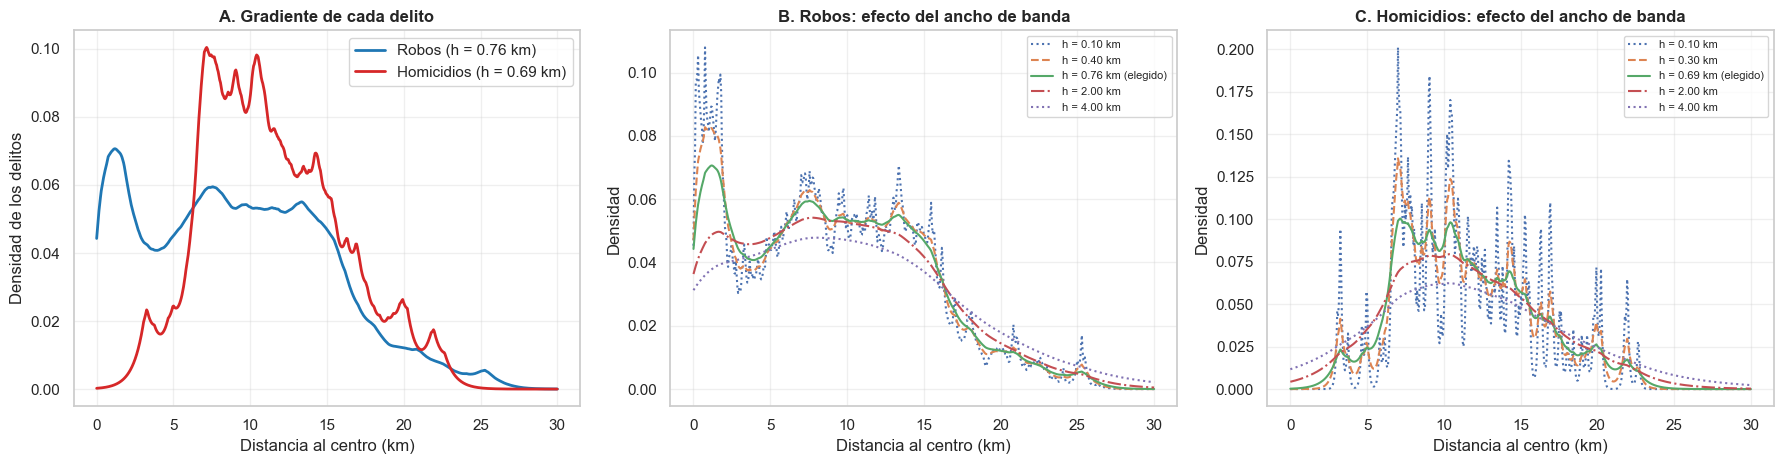

Ancho de banda usado para robos      : 0.764 km (regla de Silverman)
Ancho de banda usado para homicidios : 0.687 km (validacion cruzada)


In [28]:
# ==============================================================================
#      CURVAS DE DENSIDAD Y SENSIBILIDAD AL SUAVIZADO
# ==============================================================================
# Para los robos usamos Silverman, porque la CV es degenerada
H_ROBO = h_silverman
malla = np.linspace(0, 30, 600).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

# Panel A: densidades elegidas
ax = axes[0]
for etiqueta, v, h, color in [("Robos", d_robo, H_ROBO, "tab:blue"),
                              ("Homicidios", d_homi, H_HOMICIDIO, "tab:red")]:
    kde = KernelDensity(bandwidth=h, kernel=KERNEL_ELEGIDO).fit(v.reshape(-1, 1))
    ax.plot(malla[:, 0], np.exp(kde.score_samples(malla)), color=color, lw=2,
            label=f"{etiqueta} (h = {h:.2f} km)")
ax.set_xlabel("Distancia al centro (km)")
ax.set_ylabel("Densidad de los delitos")
ax.set_title("A. Gradiente de cada delito", fontsize=12, fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)

# Panel B: sensibilidad al ancho de banda en robos
ax = axes[1]
for h, estilo in [(0.1, ":"), (0.4, "--"), (H_ROBO, "-"), (2.0, "-."), (4.0, ":")]:
    kde = KernelDensity(bandwidth=h, kernel=KERNEL_ELEGIDO).fit(d_robo.reshape(-1, 1))
    ax.plot(malla[:, 0], np.exp(kde.score_samples(malla)), ls=estilo,
            label=f"h = {h:.2f} km" + (" (elegido)" if abs(h - H_ROBO) < 1e-9 else ""))
ax.set_xlabel("Distancia al centro (km)"); ax.set_ylabel("Densidad")
ax.set_title("B. Robos: efecto del ancho de banda", fontsize=12, fontweight="bold")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Panel C: sensibilidad en homicidios
ax = axes[2]
for h, estilo in [(0.1, ":"), (0.3, "--"), (H_HOMICIDIO, "-"), (2.0, "-."), (4.0, ":")]:
    kde = KernelDensity(bandwidth=h, kernel=KERNEL_ELEGIDO).fit(d_homi.reshape(-1, 1))
    ax.plot(malla[:, 0], np.exp(kde.score_samples(malla)), ls=estilo,
            label=f"h = {h:.2f} km" + (" (elegido)" if abs(h - H_HOMICIDIO) < 1e-9 else ""))
ax.set_xlabel("Distancia al centro (km)"); ax.set_ylabel("Densidad")
ax.set_title("C. Homicidios: efecto del ancho de banda", fontsize=12, fontweight="bold")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Ancho de banda usado para robos      : {H_ROBO:.3f} km (regla de Silverman)")
print(f"Ancho de banda usado para homicidios : {H_HOMICIDIO:.3f} km (validacion cruzada)")

## 4.3 El supuesto geométrico que esconde este procedimiento

Representar el delito como función de la distancia al centro implica un supuesto fuerte: que **la ciudad es aproximadamente radial** y que lo que ocurre a 8 km al norte es comparable con lo que ocurre a 8 km al suroeste.

Hay además un efecto puramente geométrico que conviene separar. La curva de densidad estimada describe **cómo se distribuyen los delitos según su distancia**, no **cuán denso es el delito por unidad de territorio**. Un anillo a 10 km del centro tiene mucha más superficie que uno a 2 km, así que acumulará más delitos aunque sea igual de seguro.

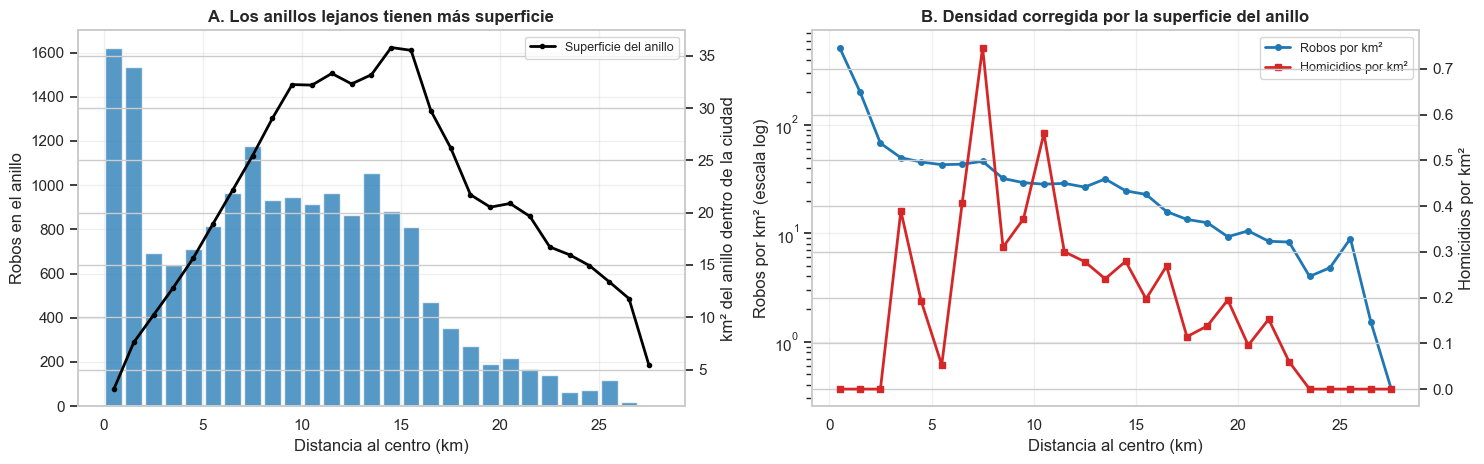

DELITO POR UNIDAD DE SUPERFICIE SEGUN EL ANILLO
 anillo_km  sup_km2  robos  robos_km2  homicidios  homicidios_km2
      0.50     3.13   1619     517.73           0            0.00
      3.50    12.84    640      49.85           5            0.39
      6.50    22.17    963      43.44           9            0.41
      9.50    32.25    946      29.33          12            0.37
     12.50    32.31    863      26.71           9            0.28
     15.50    35.53    812      22.86           7            0.20
     18.50    21.72    272      12.53           3            0.14
     21.50    19.64    166       8.45           3            0.15
     24.50    14.95     72       4.82           0            0.00
     27.50     5.47      2       0.37           0            0.00
Razon entre la densidad del primer anillo y la del ultimo: 1415 veces


In [29]:
# ==============================================================================
#   DENSIDAD DE DISTANCIAS CONTRA DENSIDAD POR UNIDAD DE SUPERFICIE
# ==============================================================================
ciudad = areas_m.union_all()
filas_anillo = []
for r in range(1, 29):
    anillo = (centro_proyectado.buffer(r * 1000)
              .difference(centro_proyectado.buffer((r - 1) * 1000))
              .intersection(ciudad))
    sup = anillo.area / 1e6
    if sup < 0.05:
        continue
    en_anillo = (delitos["dist_centro_km"] >= r - 1) & (delitos["dist_centro_km"] < r)
    n_robo = int((en_anillo & (delitos["tipo_crimen"] == "robo")).sum())
    n_homi = int((en_anillo & (delitos["tipo_crimen"] == "homicidio")).sum())
    filas_anillo.append({"anillo_km": r - 0.5, "sup_km2": sup,
                         "robos": n_robo, "homicidios": n_homi,
                         "robos_km2": n_robo / sup, "homicidios_km2": n_homi / sup})
anillos = pd.DataFrame(filas_anillo)

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
ax = axes[0]
ax.bar(anillos["anillo_km"], anillos["robos"], width=0.85, color="tab:blue", alpha=0.75)
ax2 = ax.twinx()
ax2.plot(anillos["anillo_km"], anillos["sup_km2"], color="black", lw=2, marker="o",
         ms=3, label="Superficie del anillo")
ax.set_xlabel("Distancia al centro (km)"); ax.set_ylabel("Robos en el anillo")
ax2.set_ylabel("km² del anillo dentro de la ciudad")
ax.set_title("A. Los anillos lejanos tienen más superficie", fontsize=12, fontweight="bold")
ax2.legend(loc="upper right", fontsize=9); ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(anillos["anillo_km"], anillos["robos_km2"], color="tab:blue", lw=2,
        marker="o", ms=4, label="Robos por km²")
ax.set_yscale("log")
ax.set_xlabel("Distancia al centro (km)"); ax.set_ylabel("Robos por km² (escala log)")
ax3 = ax.twinx()
ax3.plot(anillos["anillo_km"], anillos["homicidios_km2"], color="tab:red", lw=2,
         marker="s", ms=4, label="Homicidios por km²")
ax3.set_ylabel("Homicidios por km²")
lineas = ax.get_lines() + ax3.get_lines()
ax.legend(lineas, [l.get_label() for l in lineas], fontsize=9)
ax.set_title("B. Densidad corregida por la superficie del anillo",
             fontsize=12, fontweight="bold")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("=" * 86)
print("DELITO POR UNIDAD DE SUPERFICIE SEGUN EL ANILLO")
print("=" * 86)
print(anillos[anillos["anillo_km"] % 3 == 0.5][
    ["anillo_km", "sup_km2", "robos", "robos_km2", "homicidios", "homicidios_km2"]]
    .to_string(index=False, float_format=lambda v: f"{v:.2f}"))
print("=" * 86)
print(f"Razon entre la densidad del primer anillo y la del ultimo: "
      f"{anillos['robos_km2'].iloc[0] / anillos['robos_km2'].iloc[-1]:.0f} veces")

**Corregir por la superficie del anillo cambia por completo la lectura.**

En conteo bruto, el anillo de 9 a 10 km acumula más robos que el de 3 a 4 km. Pero el primero tiene 32,3 km² dentro de la ciudad y el segundo solo 12,8 km². Al dividir, la densidad cae de forma monótona: **517,7 robos por km² en el primer kilómetro, 43,4 entre 6 y 7 km, y 4,8 entre 24 y 25 km**. Entre el primer anillo y el último de la ciudad la razón llega a **1.415 veces**.

**Los dos delitos tienen gradientes de forma distinta.** El robo es máximo exactamente en el centro y decae de forma continua. El homicidio, en cambio, **es cero en el primer kilómetro**, alcanza su máximo alrededor de los 6 a 7 km con 0,41 por km², y decae después. No es un gradiente centro-periferia sino un anillo intermedio.

Esa diferencia importa para la transferencia a Bogotá. **La forma del gradiente no es una propiedad del delito sino de cómo está organizada la ciudad**: Chicago tiene un distrito financiero denso y sin residentes en el centro, rodeado de barrios residenciales. Bogotá no tiene esa estructura, y su centro histórico sí es residencial.

## 4.4 ¿Sirve este procedimiento para decidir dónde patrullar?

**No por sí solo, y conviene decirlo sin rodeos.**

El procedimiento entrega una curva que asigna un valor de densidad a cada distancia. Pero **todos los puntos que están a la misma distancia del centro reciben el mismo valor**, sin importar en qué dirección estén. La curva no distingue entre un punto a 8 km al norte, sobre la costa del lago, y otro a 8 km al suroeste, en un barrio residencial, aunque el Paso 1 mostró que tienen perfiles de delito completamente distintos.

En términos operativos, el resultado de este procedimiento es **un anillo**, no un lugar. Decirle a una patrulla que vaya "al anillo de 6 a 7 kilómetros" es señalarle 22 km² repartidos en una corona alrededor de toda la ciudad.

**Para qué sí sirve.** Es útil como **descripción estructural** y para responder preguntas de política general: si el delito se concentra hacia el centro o hacia la periferia, si esa estructura cambia entre delitos, y si cambia en el tiempo. Es un insumo de diagnóstico, no de asignación.

**Y tiene un valor adicional en este análisis**, que es haber revelado el problema de la validación cruzada. Ese hallazgo no es sobre Chicago sino sobre el método, y es el tipo de resultado que sí se transfiere a Bogotá.

### Cierre del Paso 4

1. **Las distancias se midieron en el plano proyectado EPSG:26971 y se expresan en kilómetros.** La verificación contra la distancia geodésica da una diferencia media de 0,1 metros y máxima de 0,5, con correlación de 1,00000000.
2. **Los dos delitos ocupan anillos distintos**: la mediana de distancia al centro es de 8,64 km para robos y 10,72 km para homicidios.
3. **La validación cruzada lleva el ancho de banda de los robos a una escala imposible**, entre 65 y 78 metros, más fina que la cuadra a la que los datos fueron agrupados. El 31,7% de las distancias son valores exactamente repetidos, herencia de la anonimización documentada en el Paso 1, y esos empates premian el sobreajuste.
4. **El óptimo sigue la estructura de empates y no la del delito**: al perturbar las distancias con ±50, ±150 y ±400 metros, el ancho elegido sube a 117, 157 y 211 metros respectivamente. Además, si la grilla no baja hasta esa escala, el procedimiento devuelve su propio extremo inferior sin avisar.
5. **Para los robos usamos la regla de Silverman (0,764 km)** y lo documentamos como decisión forzada por el defecto anterior.
6. **Para los homicidios la CV sí funciona** y selecciona el kernel exponencial con h = 0,687 km, con un máximo claramente interior.
7. **El kernel casi no importa.** La diferencia entre el mejor y el peor de los seis kernels es de 0,27 de log-verosimilitud, frente a más de 600 que produce mover el ancho de banda.
8. **La curva de densidad de distancias no es densidad de delito por territorio.** Corregida por la superficie de cada anillo, la densidad de robos pasa de 517,7 por km² en el primer kilómetro a 4,8 entre los 24 y 25 km, y la razón entre el primer anillo y el último llega a 1.415 veces.
9. **Los gradientes tienen forma distinta**: el robo es máximo en el centro, mientras que el homicidio es cero en el primer kilómetro y alcanza su máximo entre los 6 y 7 km.
10. **El procedimiento no sirve para asignar patrullaje** porque su salida es un anillo y no un lugar: trata igual a todos los puntos equidistantes del centro, sin importar la dirección.

# Paso 5. Puntos calientes en el plano

Los procedimientos anteriores reducen la ubicación del delito a una sola dimensión: el área administrativa a la que pertenece, o su distancia al centro. Este paso estima la densidad directamente sobre el plano, sin imponer divisiones ni geometrías previas.

Comparamos los dos criterios de selección del ancho de banda que ofrece `statsmodels`:

- **`normal_reference`**: una regla plug-in. Calcula el ancho de banda con una fórmula cerrada que supone que la distribución subyacente es aproximadamente normal, y escala con $n^{-1/6}$ en dos dimensiones. Es instantánea.
- **`cv_ml`**: validación cruzada por máxima verosimilitud. Busca numéricamente el ancho de banda que maximiza la verosimilitud dejando fuera cada observación. No supone normalidad, pero es mucho más costosa.

Trabajamos en coordenadas proyectadas expresadas en **kilómetros**, para que los anchos de banda se lean directamente como distancias.

In [30]:
# ==============================================================================
#       PREPARACION: COORDENADAS EN KILOMETROS Y GRILLA DE EVALUACION
# ==============================================================================
import statsmodels.api as sm
from scipy.spatial import cKDTree

delitos["x_km"] = puntos_m.geometry.x / 1000
delitos["y_km"] = puntos_m.geometry.y / 1000

datos_robo = delitos.loc[delitos["tipo_crimen"] == "robo", ["x_km", "y_km"]].values
datos_homi = delitos.loc[delitos["tipo_crimen"] == "homicidio", ["x_km", "y_km"]].values

# Grilla regular de 500 m sobre el rectangulo que contiene la ciudad
PASO_GRILLA = 0.5
minx, miny, maxx, maxy = [v / 1000 for v in areas_m.total_bounds]
gx = np.arange(minx, maxx + PASO_GRILLA, PASO_GRILLA)
gy = np.arange(miny, maxy + PASO_GRILLA, PASO_GRILLA)
XX, YY = np.meshgrid(gx, gy)
grilla = np.column_stack([XX.ravel(), YY.ravel()])

nodos = gpd.GeoSeries([Point(x * 1000, y * 1000) for x, y in grilla], crs=CRS_METRICO)
dentro_ciudad = nodos.within(areas_m.union_all()).values

print("=" * 78)
print("GRILLA DE EVALUACION")
print("=" * 78)
print(f"Paso de la grilla : {PASO_GRILLA*1000:.0f} m")
print(f"Nodos totales     : {len(grilla):,}")
print(f"Nodos dentro de la ciudad: {int(dentro_ciudad.sum()):,}")
print(f"Extension de la ciudad: {maxx-minx:.1f} km (este-oeste) x {maxy-miny:.1f} km (norte-sur)")
print("=" * 78)

GRILLA DE EVALUACION
Paso de la grilla : 500 m
Nodos totales     : 6,035
Nodos dentro de la ciudad: 2,392
Extension de la ciudad: 34.8 km (este-oeste) x 42.0 km (norte-sur)


In [31]:
# ==============================================================================
#     ANCHOS DE BANDA SEGUN CADA CRITERIO
# ==============================================================================
# cv_ml sobre los 17.603 robos tarda cerca de 29 minutos. Para que el cuaderno
# sea ejecutable dejamos el valor calculado y un interruptor para reproducirlo.
RECALCULAR_CVML_ROBO = False
BW_CVML_ROBO_PRECALCULADO = [0.4416, 0.0169]   # obtenido en 1.735 s

bw_nr_robo = sm.nonparametric.KDEMultivariate(
    data=datos_robo, var_type="cc", bw="normal_reference").bw
bw_nr_homi = sm.nonparametric.KDEMultivariate(
    data=datos_homi, var_type="cc", bw="normal_reference").bw
bw_cv_homi = sm.nonparametric.KDEMultivariate(
    data=datos_homi, var_type="cc", bw="cv_ml").bw

if RECALCULAR_CVML_ROBO:
    bw_cv_robo = sm.nonparametric.KDEMultivariate(
        data=datos_robo, var_type="cc", bw="cv_ml").bw
else:
    bw_cv_robo = np.array(BW_CVML_ROBO_PRECALCULADO)

print("=" * 82)
print("ANCHOS DE BANDA SELECCIONADOS (kilometros)")
print("=" * 82)
print(f"{'delito':12} {'criterio':20} {'h este-oeste':>14} {'h norte-sur':>13}")
for etq, crit, bw in [("robo", "normal_reference", bw_nr_robo),
                      ("robo", "cv_ml", bw_cv_robo),
                      ("homicidio", "normal_reference", bw_nr_homi),
                      ("homicidio", "cv_ml", bw_cv_homi)]:
    print(f"{etq:12} {crit:20} {bw[0]:14.4f} {bw[1]:13.4f}")
print("=" * 82)
print(f"En metros, el menor de todos: {min(bw_cv_robo)*1000:.0f} m")

ANCHOS DE BANDA SELECCIONADOS (kilometros)
delito       criterio               h este-oeste   h norte-sur
robo         normal_reference             0.9537        1.8852
robo         cv_ml                        0.4416        0.0169
homicidio    normal_reference             2.3556        3.7252
homicidio    cv_ml                        0.8767        1.5558
En metros, el menor de todos: 17 m


In [32]:
# ==============================================================================
#   ¿COMO ESCALA cv_ml CON EL TAMANO DE LA MUESTRA?
# ==============================================================================
# La teoria dice que en dos dimensiones el ancho optimo cae como n^(-1/6)
rng_bw = np.random.RandomState(RANDOM_STATE)
filas_escala = []
h_base = None
for n in [300, 600, 1200, 2400]:
    sub = datos_robo[rng_bw.choice(len(datos_robo), n, replace=False)]
    bw = sm.nonparametric.KDEMultivariate(data=sub, var_type="cc", bw="cv_ml").bw
    if h_base is None:
        h_base = (bw[0], n)
    filas_escala.append({
        "n": n,
        "h_x_observado": bw[0],
        "h_y_observado": bw[1],
        "h_x_esperado_teoria": h_base[0] * (n / h_base[1]) ** (-1 / 6),
    })
escala_cvml = pd.DataFrame(filas_escala)
escala_cvml["razon_obs_teoria"] = (escala_cvml["h_x_observado"] /
                                   escala_cvml["h_x_esperado_teoria"])

print("=" * 88)
print("cv_ml SOBRE LOS ROBOS: LO OBSERVADO CONTRA LO QUE PREDICE LA TEORIA")
print("=" * 88)
print(escala_cvml.to_string(index=False, float_format=lambda v: f"{v:.4f}"))
print("=" * 88)
print("Con la muestra completa (n = 17.603) el ancho norte-sur cae a "
      f"{bw_cv_robo[1]*1000:.0f} metros.")

cv_ml SOBRE LOS ROBOS: LO OBSERVADO CONTRA LO QUE PREDICE LA TEORIA
   n  h_x_observado  h_y_observado  h_x_esperado_teoria  razon_obs_teoria
 300         1.1995         1.3518               1.1995            1.0000
 600         0.5824         1.0153               1.0687            0.5450
1200         0.3787         0.8347               0.9521            0.3977
2400         0.1850         0.7086               0.8482            0.2181
Con la muestra completa (n = 17.603) el ancho norte-sur cae a 17 metros.


**Los dos criterios no discrepan en el margen: discrepan en órdenes de magnitud.**

Para los robos, `normal_reference` propone suavizar con **0,95 km de este a oeste y 1,89 de norte a sur**. La asimetría tiene sentido, porque Chicago mide 32,8 km en un eje y 41,9 en el otro, y el delito se dispersa más en la dirección larga.

`cv_ml` propone **0,44 km y 17 metros**. Diecisiete metros es menos que el ancho de una calle. La superficie de densidad que produce no es un mapa de calor sino un conjunto de crestas casi verticales, una por cada cuadra con robos. Y la asimetría queda invertida respecto a la geometría de la ciudad.

**No es un error numérico aislado sino el mismo problema del Paso 4, ahora en dos dimensiones.** La tabla de escalamiento lo muestra: la teoría dice que el ancho óptimo debe caer como $n^{-1/6}$, pero el observado cae mucho más rápido, y la brecha crece con la muestra. A 2.400 puntos el ancho observado ya es varias veces menor que el teórico. La causa es la misma: el 41,8% de los delitos comparte coordenada exacta con otro, y esos empates premian el sobreajuste sin límite.

**Con los homicidios los dos criterios se comportan bien**, y la diferencia entre ellos es la esperable: `normal_reference` pide 2,36 y 3,73 km, mientras que `cv_ml` pide 0,88 y 1,56 km, unas 2,4 veces menos.

Conviene notar lo que significa ese 3,73 km de `normal_reference`: con solo 144 homicidios, la regla plug-in reparte cada caso sobre un radio comparable al tamaño de varias áreas comunitarias. **No es un defecto de la regla sino una consecuencia de tener pocos datos**, y es coherente con lo que el Paso 2 ya había medido sobre la fragilidad de la evidencia de homicidios.

## 5.1 Mapas de densidad con curvas de nivel

Superficies de densidad estimadas: 4


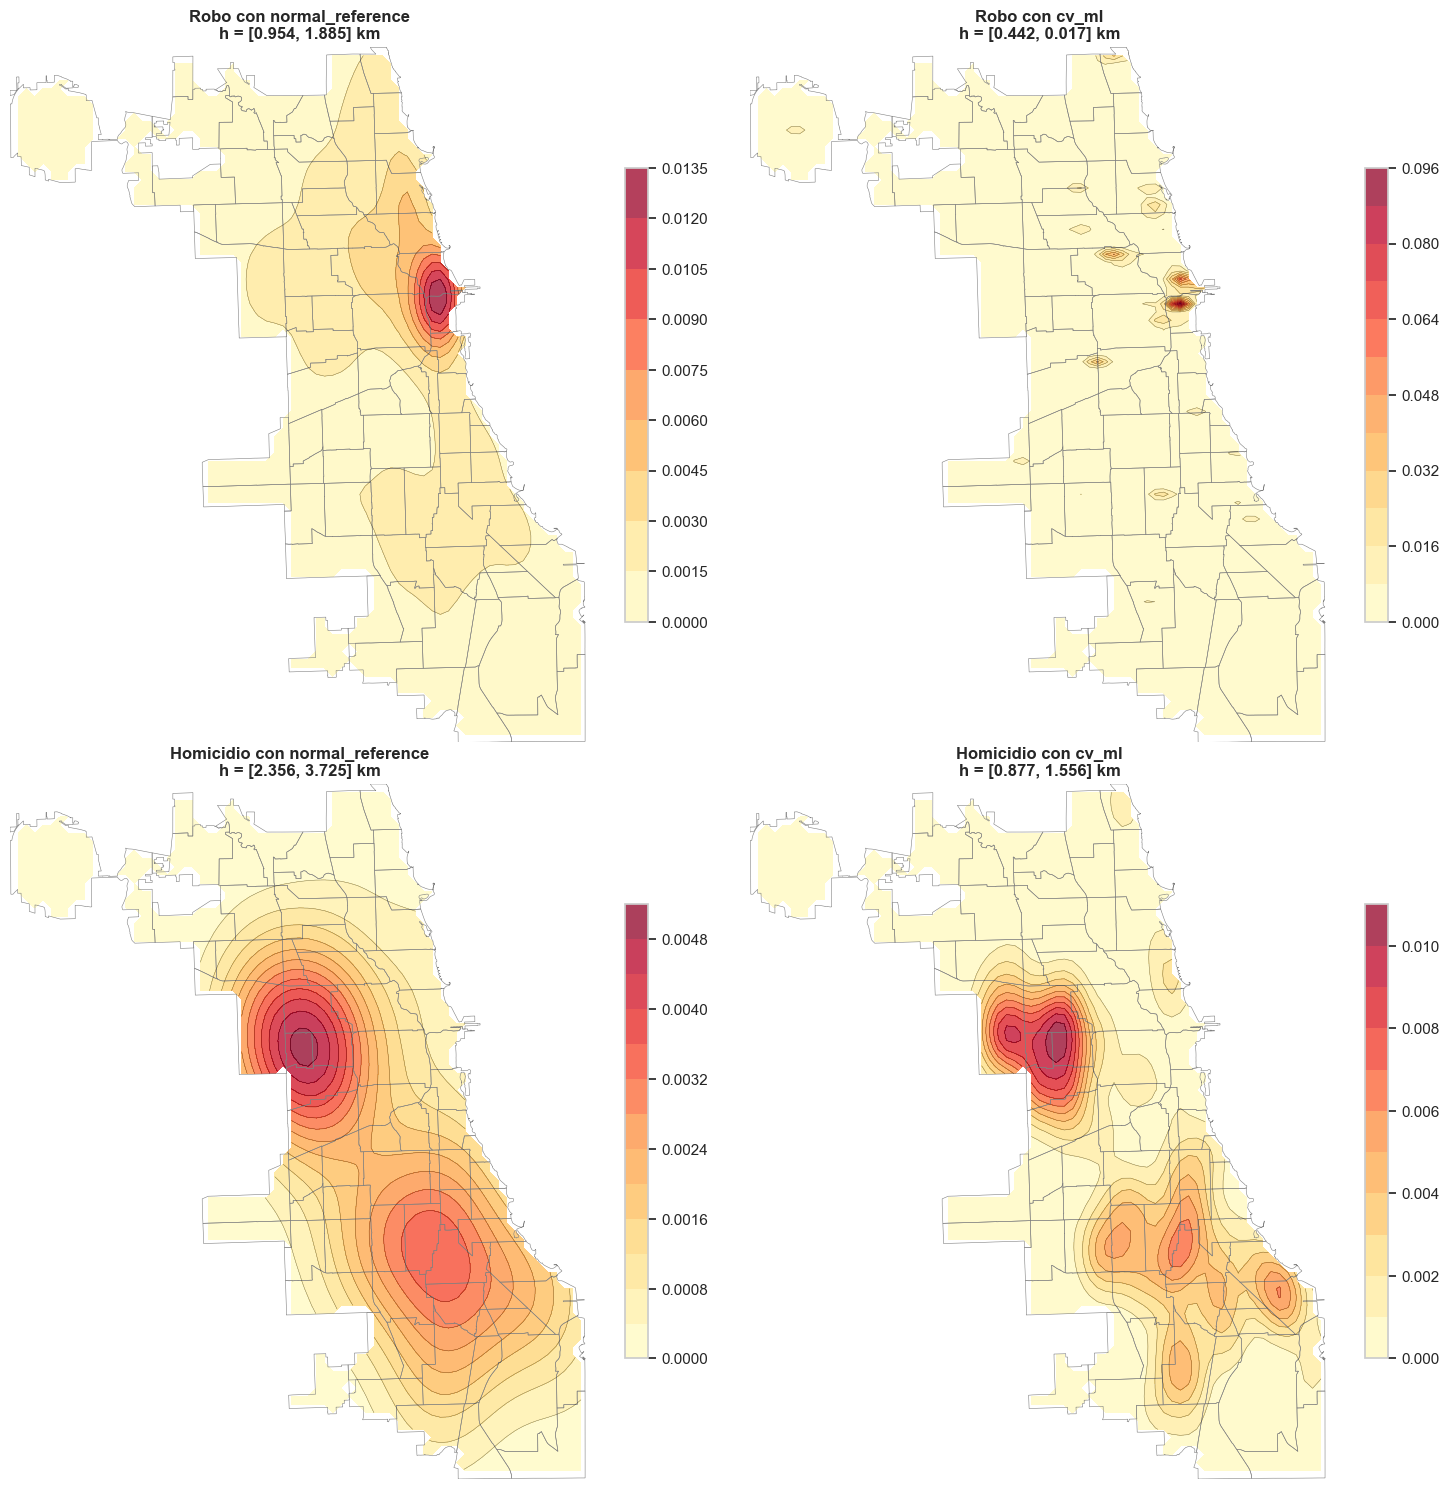

In [33]:
# ==============================================================================
#      ESTIMACION DE LA DENSIDAD SOBRE LA GRILLA
# ==============================================================================
def estimar_densidad(datos, bw):
    modelo = sm.nonparametric.KDEMultivariate(data=datos, var_type="cc", bw=bw)
    d = modelo.pdf(grilla)
    d = np.where(dentro_ciudad, d, np.nan)
    return d

superficies = {
    ("robo", "normal_reference"): estimar_densidad(datos_robo, bw_nr_robo),
    ("robo", "cv_ml"): estimar_densidad(datos_robo, bw_cv_robo),
    ("homicidio", "normal_reference"): estimar_densidad(datos_homi, bw_nr_homi),
    ("homicidio", "cv_ml"): estimar_densidad(datos_homi, bw_cv_homi),
}
print("Superficies de densidad estimadas:", len(superficies))

fig, axes = plt.subplots(2, 2, figsize=(15, 15))
for ax, ((delito, criterio), dens) in zip(axes.ravel(), superficies.items()):
    areas_m.boundary.plot(ax=ax, color="gray", linewidth=0.4)
    Z = dens.reshape(XX.shape)
    cf = ax.contourf(XX * 1000, YY * 1000, Z, levels=12, cmap="YlOrRd", alpha=0.75)
    ax.contour(XX * 1000, YY * 1000, Z, levels=12, colors="black",
               linewidths=0.35, alpha=0.5)
    bw = {"normal_reference": {"robo": bw_nr_robo, "homicidio": bw_nr_homi},
          "cv_ml": {"robo": bw_cv_robo, "homicidio": bw_cv_homi}}[criterio][delito]
    ax.set_title(f"{delito.title()} con {criterio}\nh = [{bw[0]:.3f}, {bw[1]:.3f}] km",
                 fontsize=12, fontweight="bold")
    ax.set_axis_off()
    plt.colorbar(cf, ax=ax, shrink=0.65)
plt.tight_layout()
plt.show()

**Los cuatro mapas muestran por qué la elección del ancho de banda es la decisión central.**

Con `normal_reference`, los robos dibujan una mancha compacta y legible sobre el distrito central. Con `cv_ml`, la misma información se fragmenta en franjas estrechas que siguen la retícula de calles: el ancho de 17 metros en el eje norte-sur convierte cada corredor de robos en una línea.

En los homicidios el contraste es distinto. `normal_reference` produce una mancha tan extendida que cubre buena parte del oeste de la ciudad sin distinguir nada dentro de ella. `cv_ml`, con un ancho tres veces menor, sí separa focos individuales.

**El mismo criterio da el mejor resultado en un delito y el peor en el otro**, y la razón es el número de observaciones: `cv_ml` sobreajusta cuando hay 17.603 puntos con coordenadas repetidas y funciona bien cuando hay 144 sin repeticiones.

## 5.2 ¿Qué tan distintos son los puntos calientes que identifica cada método?

In [34]:
# ==============================================================================
#     COINCIDENCIA ENTRE LOS PUNTOS CALIENTES DE CADA CRITERIO
# ==============================================================================
def top_celdas(dens, k):
    return set(np.argsort(-np.nan_to_num(dens, nan=-1))[:k])

print("=" * 78)
print("CELDAS EN COMUN ENTRE normal_reference Y cv_ml")
print("=" * 78)
print(f"{'delito':12} {'top 10':>10} {'top 25':>10} {'top 50':>10}")
for delito in ["robo", "homicidio"]:
    a = superficies[(delito, "normal_reference")]
    b = superficies[(delito, "cv_ml")]
    fila = [len(top_celdas(a, k) & top_celdas(b, k)) for k in (10, 25, 50)]
    print(f"{delito:12} {f'{fila[0]}/10':>10} {f'{fila[1]}/25':>10} {f'{fila[2]}/50':>10}")
print("=" * 78)

# ¿En que areas comunitarias caen los puntos calientes de cada metodo?
nodos_gdf = gpd.GeoDataFrame(geometry=nodos, crs=CRS_METRICO)
nodos_gdf = gpd.sjoin(nodos_gdf, areas_m[["community", "geometry"]],
                      how="left", predicate="within")
nodos_gdf = nodos_gdf[~nodos_gdf.index.duplicated(keep="first")]
comunidad_nodo = nodos_gdf["community"].values

print()
print("AREAS COMUNITARIAS DONDE CAEN LAS 10 CELDAS MAS DENSAS")
for (delito, criterio), dens in superficies.items():
    top = sorted(top_celdas(dens, 10))
    comunidades = pd.Series(comunidad_nodo[top]).dropna().unique()
    print(f"  {delito:10} {criterio:18} {', '.join(c.title() for c in comunidades)}")

CELDAS EN COMUN ENTRE normal_reference Y cv_ml
delito           top 10     top 25     top 50
robo               3/10       9/25      21/50
homicidio          3/10      15/25      39/50

AREAS COMUNITARIAS DONDE CAEN LAS 10 CELDAS MAS DENSAS
  robo       normal_reference   Loop, Near North Side
  robo       cv_ml              South Lawndale, Loop, Near North Side, West Town
  homicidio  normal_reference   West Garfield Park, East Garfield Park, Humboldt Park
  homicidio  cv_ml              East Garfield Park, West Garfield Park, Humboldt Park


**Los dos métodos coinciden en el barrio y discrepan en la cuadra.**

De las diez celdas más densas, **solo tres coinciden** entre los dos criterios, tanto en robos como en homicidios. Al ampliar a las cincuenta primeras la coincidencia sube a 21 de 50 en robos y 39 de 50 en homicidios.

Pero si en lugar de celdas se miran las áreas comunitarias donde caen esas celdas, el panorama cambia: ambos métodos señalan el Loop y Near North Side para robos, y el corredor de Garfield Park y Humboldt Park para homicidios. **La discrepancia no es sobre qué zona de la ciudad está caliente sino sobre en qué punto exacto dentro de ella se debe parar la patrulla.**

Esa distinción importa para el cliente. Si el protocolo de focalización opera a nivel de barrio, los dos criterios son equivalentes. Si opera a nivel de esquina, que es lo que promete un mapa de calor, **la elección del ancho de banda determina siete de cada diez destinos**.

## 5.3 Sensibilidad al nivel de suavizado

In [35]:
# ==============================================================================
#     ¿CUANTO CAMBIA EL TOP AL MULTIPLICAR EL ANCHO DE BANDA?
# ==============================================================================
dens_base = superficies[("robo", "normal_reference")]
top_base = top_celdas(dens_base, 25)

filas_sens = []
for factor in [0.5, 0.75, 1.0, 1.5, 2.0, 3.0]:
    d = estimar_densidad(datos_robo, bw_nr_robo * factor)
    filas_sens.append({
        "factor": factor,
        "h_x_km": bw_nr_robo[0] * factor,
        "h_y_km": bw_nr_robo[1] * factor,
        "celdas_en_comun_top25": len(top_base & top_celdas(d, 25)),
    })
sensibilidad = pd.DataFrame(filas_sens)

print("=" * 78)
print("ESTABILIDAD DEL TOP 25 AL ESCALAR EL ANCHO DE BANDA (robos)")
print("=" * 78)
print(sensibilidad.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print("=" * 78)
print("Escalar los dos anchos a la vez conserva el top mientras el factor")
print("se mantenga entre 0,5 y 1,5. Cambiar la RAZON entre ellos, en cambio,")
print("es lo que separa a normal_reference de cv_ml: 1,89 / 0,95 = 2,0 contra")
print(f"{bw_cv_robo[1]:.4f} / {bw_cv_robo[0]:.4f} = {bw_cv_robo[1]/bw_cv_robo[0]:.3f}.")

ESTABILIDAD DEL TOP 25 AL ESCALAR EL ANCHO DE BANDA (robos)
 factor  h_x_km  h_y_km  celdas_en_comun_top25
  0.500   0.477   0.943                     22
  0.750   0.715   1.414                     23
  1.000   0.954   1.885                     25
  1.500   1.431   2.828                     23
  2.000   1.907   3.770                     17
  3.000   2.861   5.656                      6
Escalar los dos anchos a la vez conserva el top mientras el factor
se mantenga entre 0,5 y 1,5. Cambiar la RAZON entre ellos, en cambio,
es lo que separa a normal_reference de cv_ml: 1,89 / 0,95 = 2,0 contra
0.0169 / 0.4416 = 0.038.


**El resultado es robusto a la escala y frágil a la forma.**

Multiplicar los dos anchos de banda por un factor común entre 0,5 y 1,5 conserva **22 o 23 de las 25 celdas prioritarias**. Duplicarlos deja 17 de 25 y triplicarlos solo 6. Dentro de un rango razonable, equivocarse en la magnitud del suavizado no cambia mucho las prioridades.

Lo que sí las cambia es **la razón entre los dos anchos**, es decir la forma del kernel. `normal_reference` usa una razón norte-sur sobre este-oeste de 2,0, coherente con la forma alargada de la ciudad. `cv_ml` usa 0,038, lo que equivale a un kernel aplastado en la dirección contraria.

Esto matiza la afirmación habitual de que el ancho de banda es el parámetro crítico. Lo es, pero en un problema bivariado **hay dos anchos, y la relación entre ellos importa más que su magnitud común**.

## 5.4 De una superficie continua a una lista de lugares para patrullar

Un mapa de calor no es una orden de patrullaje. Para convertirlo en una lista hay que tomar al menos cuatro decisiones adicionales, y ninguna sale de los datos.

In [36]:
# ==============================================================================
#   ¿CUANTA SUPERFICIE HAY QUE CUBRIR PARA CAPTURAR QUE PORCENTAJE DEL DELITO?
# ==============================================================================
arbol = cKDTree(grilla)
_, celda_de_cada_robo = arbol.query(datos_robo)

filas_cobertura = []
for criterio in ["normal_reference", "cv_ml"]:
    dens = superficies[("robo", criterio)]
    orden = np.argsort(-np.nan_to_num(dens, nan=-1))
    for n_celdas in [20, 50, 100, 200]:
        seleccion = set(orden[:n_celdas].tolist())
        capturados = np.isin(celda_de_cada_robo, list(seleccion)).mean() * 100
        superficie = n_celdas * PASO_GRILLA ** 2
        filas_cobertura.append({
            "criterio": criterio,
            "celdas": n_celdas,
            "km2": superficie,
            "pct_ciudad": superficie / areas_m["km2"].sum() * 100,
            "pct_robos_capturados": capturados,
            "concentracion": capturados / (superficie / areas_m["km2"].sum() * 100),
        })
cobertura = pd.DataFrame(filas_cobertura)

print("=" * 96)
print("EFICIENCIA DE LA FOCALIZACION: QUE SE CAPTURA POR CADA KM2 QUE SE PATRULLA")
print("=" * 96)
print(cobertura.to_string(index=False, float_format=lambda v: f"{v:.2f}"))
print("=" * 96)
print("concentracion = cuantas veces mas robos por km2 que patrullar al azar")
print()
print("Comparacion con los procedimientos de los pasos anteriores:")
print("   77 areas comunitarias, top 10 : 46,3% de los robos en 16,3% de la ciudad -> 2,8x")
print("   grilla de 1 km, top 10        : 18,3% de los robos en  1,7% de la ciudad -> 10,9x")
print(f"   KDE, 20 celdas de 500 m       : {cobertura.iloc[0].pct_robos_capturados:.1f}% "
      f"de los robos en {cobertura.iloc[0].pct_ciudad:.1f}% de la ciudad -> "
      f"{cobertura.iloc[0].concentracion:.1f}x")

EFICIENCIA DE LA FOCALIZACION: QUE SE CAPTURA POR CADA KM2 QUE SE PATRULLA
        criterio  celdas   km2  pct_ciudad  pct_robos_capturados  concentracion
normal_reference      20  5.00        0.84                 13.71          16.41
normal_reference      50 12.50        2.09                 19.33           9.25
normal_reference     100 25.00        4.18                 24.96           5.97
normal_reference     200 50.00        8.36                 35.56           4.25
           cv_ml      20  5.00        0.84                 11.54          13.81
           cv_ml      50 12.50        2.09                 18.83           9.01
           cv_ml     100 25.00        4.18                 26.63           6.37
           cv_ml     200 50.00        8.36                 36.89           4.41
concentracion = cuantas veces mas robos por km2 que patrullar al azar

Comparacion con los procedimientos de los pasos anteriores:
   77 areas comunitarias, top 10 : 46,3% de los robos en 16,3% de la ciuda

**El KDE es el procedimiento más eficiente de los evaluados, con una diferencia amplia.**

Veinte celdas de 500 metros, que suman **5 km² o el 0,84% de la ciudad**, capturan el **13,7% de los robos**. Eso es **16,4 veces más robos por kilómetro cuadrado que patrullar al azar**, frente a 10,9 veces de la mejor grilla del Paso 3 y 2,8 veces del ranking por áreas comunitarias.

La relación tiene rendimientos decrecientes claros: doblar la superficie no dobla la captura. Con 200 celdas, 50 km² y el 8,4% de la ciudad, se captura el 35,6%, pero la concentración baja a 4,3 veces.

**Y los dos criterios de ancho de banda rinden casi igual en esta métrica**, con 13,7% contra 11,5% en las primeras 20 celdas y 35,6% contra 36,9% en las primeras 200. Es un matiz importante: aunque `cv_ml` produce un mapa visualmente absurdo, **no captura menos delito**. El problema de sus 17 metros no es la eficiencia sino la interpretabilidad y la estabilidad, que examinamos en la sección anterior.

**Las cuatro decisiones que el mapa no toma por uno.**

**Cuántas celdas activar.** La superficie de densidad es continua y no tiene un corte natural. Fijar el umbral es decidir cuánto territorio cubre la operación, y depende del número de patrullas disponibles, no de los datos.

**Qué tamaño de celda usar.** Usamos 500 metros porque es comparable al recorrido de una patrulla a pie, pero el mismo mapa con celdas de 100 metros o de 2 km daría listas distintas. Es el mismo problema de unidad de área modificable del Paso 3, que el KDE reduce pero no elimina: la superficie es continua, la lista no.

**Qué delito priorizar.** Las superficies de robo y homicidio señalan zonas distintas, como viene mostrando el análisis desde el Paso 1. Una lista única exige la ponderación que el Paso 2 dejó explícitamente en manos del cliente.

**Cada cuánto recalcular.** El mapa se estimó con un verano completo. Una operación real necesita decidir si actualiza semanal, mensual o por temporada, y con cuánta historia. El Paso 2 mostró que con pocos casos el ranking no es reproducible, así que ventanas cortas darían listas inestables por puro azar.

### Cierre del Paso 5

1. **Los dos criterios de ancho de banda discrepan en órdenes de magnitud para los robos.** `normal_reference` propone 0,95 y 1,89 km; `cv_ml` propone 0,44 km y **17 metros**.
2. **Es el mismo problema del Paso 4 en dos dimensiones.** El ancho que elige `cv_ml` cae mucho más rápido que el $n^{-1/6}$ que predice la teoría, y la brecha crece con la muestra, porque el 41,8% de los delitos comparte coordenada exacta.
3. **Con los homicidios ambos criterios funcionan**: 2,36 y 3,73 km con `normal_reference`, 0,88 y 1,56 con `cv_ml`. El primero suaviza sobre un radio comparable a varias áreas comunitarias, consecuencia directa de tener solo 144 casos.
4. **El mismo criterio es el mejor en un delito y el peor en el otro**, lo que depende del número de observaciones y no de la bondad del método.
5. **Los métodos coinciden en el barrio y discrepan en la cuadra.** Solo 3 de las 10 celdas más densas coinciden, pero ambos señalan el Loop y Near North Side para robos y el corredor de Garfield Park para homicidios.
6. **El resultado es robusto a la escala del suavizado y frágil a su forma.** Escalar ambos anchos entre 0,5 y 1,5 conserva 22 o 23 de 25 celdas; lo que separa a los dos criterios es la razón entre ellos, de 2,0 contra 0,038.
7. **El KDE es el procedimiento más eficiente de los evaluados**: 20 celdas de 500 metros, el 0,84% de la ciudad, capturan el 13,7% de los robos, una concentración de 16,4 veces frente a 10,9 de la mejor grilla y 2,8 del ranking por áreas.
8. **Los dos criterios capturan casi el mismo delito** pese a producir mapas muy distintos. El problema de `cv_ml` no es la eficiencia sino la interpretabilidad y la estabilidad.
9. **Pasar de la superficie a una lista exige cuatro decisiones que los datos no contienen**: cuántas celdas activar, de qué tamaño, con qué delito y cada cuánto recalcular.

# Paso 6. ¿Qué explica la ubicación de los puntos calientes?

Hasta aquí describimos **dónde** se concentra el delito. Este paso explora **con qué características del espacio** se asocia esa concentración, usando datos de OpenStreetMap sobre uso comercial del suelo.

Conviene anunciar desde el principio el límite del ejercicio. Lo que sigue son **correlaciones espaciales entre agregados por área comunitaria**. No son explicaciones causales ni evidencia sobre si patrullar esos lugares reduciría el delito. La sección final del paso separa explícitamente esos tres niveles, porque confundirlos es el error más costoso que podría cometer esta consultoría.

## 6.1 Obtención de los datos de OpenStreetMap

**Una nota sobre las herramientas.** El material del curso usa `pyrosm` para acceder a OpenStreetMap. Esa librería no se pudo instalar en este entorno porque falla la compilación de una de sus dependencias (`cykhash`). Usamos en su lugar **`osmnx`**, que consulta la API Overpass y entrega los mismos objetos como `GeoDataFrame`. Es un cambio de herramienta, no de fuente ni de método.

Descargamos tres capas, y guardamos una copia local para que el cuaderno sea reproducible sin conexión.

In [37]:
# ==============================================================================
#        DESCARGA DE CAPAS DE OPENSTREETMAP (con copia local)
# ==============================================================================
import os
import osmnx as ox

CARPETA_OSM = "data/osm_cache"
os.makedirs(CARPETA_OSM, exist_ok=True)

def capa_osm(nombre, tags):
    """Descarga una capa de OSM o la lee del cache local si ya existe."""
    ruta = f"{CARPETA_OSM}/{nombre}.gpkg"
    if os.path.exists(ruta):
        print(f"  {nombre}: leido del cache local")
        return gpd.read_file(ruta)
    print(f"  {nombre}: descargando de OpenStreetMap...")
    capa = ox.features_from_polygon(areas.union_all(), tags=tags)
    capa = capa.reset_index()[["geometry"] +
                              [c for c in capa.columns if c in tags]]
    capa.to_file(ruta, driver="GPKG")
    return capa

print("=" * 78)
print("CAPAS DE OPENSTREETMAP")
print("=" * 78)
uso_comercial = capa_osm("comercial", {"landuse": ["commercial", "retail"]})
uso_residencial = capa_osm("residencial", {"landuse": ["residential"]})
comercios = capa_osm("comercios", {"shop": True})

uso_comercial = uso_comercial[uso_comercial.geom_type.isin(["Polygon", "MultiPolygon"])]
uso_residencial = uso_residencial[uso_residencial.geom_type.isin(["Polygon", "MultiPolygon"])]
comercios_pt = comercios[comercios.geom_type == "Point"]

print()
print(f"Poligonos de uso comercial o minorista : {len(uso_comercial):,}")
print(f"Poligonos de uso residencial           : {len(uso_residencial):,}")
print(f"Puntos con etiqueta shop               : {len(comercios_pt):,}")
print("=" * 78)

CAPAS DE OPENSTREETMAP
  comercial: descargando de OpenStreetMap...


  residencial: descargando de OpenStreetMap...


  comercios: descargando de OpenStreetMap...



Poligonos de uso comercial o minorista : 4,230
Poligonos de uso residencial           : 5,428
Puntos con etiqueta shop               : 4,165


In [38]:
# ==============================================================================
#      SUPERFICIE COMERCIAL Y COMERCIOS POR AREA COMUNITARIA
# ==============================================================================
com_m = uso_comercial.to_crs(CRS_METRICO)[["geometry"]]
res_m = uso_residencial.to_crs(CRS_METRICO)[["geometry"]]
pts_com = comercios_pt.to_crs(CRS_METRICO)[["geometry"]]

base_areas = areas_m[["area_num", "community", "km2", "geometry"]]

def superficie_por_area(capa):
    inter = gpd.overlay(base_areas, capa, how="intersection")
    return inter.groupby("area_num").geometry.apply(lambda g: g.area.sum() / 1e6)

sup_comercial = superficie_por_area(com_m)
sup_residencial = superficie_por_area(res_m)
conteo_comercios = (gpd.sjoin(pts_com, base_areas[["area_num", "geometry"]],
                              predicate="within").groupby("area_num").size())

tabla["com_km2"] = tabla["area_num"].map(sup_comercial).fillna(0.0)
tabla["com_pct"] = tabla["com_km2"] / tabla["km2"] * 100
tabla["res_pct"] = (tabla["area_num"].map(sup_residencial).fillna(0.0) /
                    tabla["km2"] * 100)
tabla["comercios"] = tabla["area_num"].map(conteo_comercios).fillna(0).astype(int)
tabla["comercios_km2"] = tabla["comercios"] / tabla["km2"]

print("=" * 82)
print("USO DEL SUELO EN CHICAGO SEGUN OPENSTREETMAP")
print("=" * 82)
print(f"Superficie comercial total   : {tabla['com_km2'].sum():.1f} km2 "
      f"({tabla['com_km2'].sum()/tabla['km2'].sum()*100:.1f}% de la ciudad)")
print(f"Comercios georreferenciados  : {tabla['comercios'].sum():,}")
print(f"Proporcion comercial por area: mediana {tabla['com_pct'].median():.2f}% | "
      f"maximo {tabla['com_pct'].max():.2f}%")
print()
print("Las cinco areas con mayor proporcion comercial:")
print(tabla.nlargest(5, "com_pct")[["community", "com_pct", "comercios",
                                     "robo", "homicidio"]]
      .to_string(index=False, float_format=lambda v: f"{v:.2f}"))
print("=" * 82)

USO DEL SUELO EN CHICAGO SEGUN OPENSTREETMAP
Superficie comercial total   : 35.3 km2 (5.9% de la ciudad)
Comercios georreferenciados  : 4,165
Proporcion comercial por area: mediana 5.54% | maximo 27.82%

Las cinco areas con mayor proporcion comercial:
      community  com_pct  comercios  robo  homicidio
NEAR NORTH SIDE    27.82        390  1559          0
           LOOP    27.13        212  1589          0
 NEAR WEST SIDE    18.22        245   912          2
NEAR SOUTH SIDE    15.83         27   145          0
       AVONDALE    14.14         77   180          0


In [39]:
# ==============================================================================
#       CORRELACIONES ENTRE USO DEL SUELO Y DELITO
# ==============================================================================
pares_corr = [
    ("Superficie comercial (km2)", "com_km2", "Robos", "robo"),
    ("Superficie comercial (km2)", "com_km2", "Homicidios", "homicidio"),
    ("% del área que es comercial", "com_pct", "Robos por km2", "robo_km2"),
    ("% del área que es comercial", "com_pct", "Homicidios por km2", "homicidio_km2"),
    ("Comercios por km2", "comercios_km2", "Robos por km2", "robo_km2"),
    ("Comercios por km2", "comercios_km2", "Homicidios por km2", "homicidio_km2"),
    ("% del área que es residencial", "res_pct", "Robos por km2", "robo_km2"),
    ("% del área que es residencial", "res_pct", "Homicidios por km2", "homicidio_km2"),
]

filas_corr = []
for etq_x, col_x, etq_y, col_y in pares_corr:
    rp = stats.pearsonr(tabla[col_x], tabla[col_y])
    rs = stats.spearmanr(tabla[col_x], tabla[col_y])
    filas_corr.append({"caracteristica": etq_x, "delito": etq_y,
                       "pearson": rp.statistic, "p_pearson": rp.pvalue,
                       "spearman": rs.statistic})
correlaciones = pd.DataFrame(filas_corr)

print("=" * 96)
print("CORRELACION ENTRE USO DEL SUELO Y DELITO (77 areas comunitarias)")
print("=" * 96)
print(correlaciones.to_string(index=False, float_format=lambda v: f"{v:.3f}"))
print("=" * 96)

# ¿Depende del centro, como pasaba en el Paso 2?
sin_centro = tabla[~tabla["community"].isin(["LOOP", "NEAR NORTH SIDE"])]
print()
print("ROBUSTEZ: ¿SE SOSTIENE AL EXCLUIR EL DISTRITO CENTRAL?")
for etq, col_x, col_y in [("Comercios por km2 vs robos por km2", "comercios_km2", "robo_km2"),
                          ("% comercial vs robos por km2", "com_pct", "robo_km2")]:
    con = stats.pearsonr(tabla[col_x], tabla[col_y]).statistic
    sin = stats.pearsonr(sin_centro[col_x], sin_centro[col_y]).statistic
    print(f"  {etq:38} con centro {con:+.3f} | sin centro {sin:+.3f}")

CORRELACION ENTRE USO DEL SUELO Y DELITO (77 areas comunitarias)
               caracteristica             delito  pearson  p_pearson  spearman
   Superficie comercial (km2)              Robos    0.649      0.000     0.542
   Superficie comercial (km2)         Homicidios   -0.092      0.427    -0.081
  % del área que es comercial      Robos por km2    0.726      0.000     0.478
  % del área que es comercial Homicidios por km2   -0.228      0.046    -0.182
            Comercios por km2      Robos por km2    0.806      0.000     0.583
            Comercios por km2 Homicidios por km2   -0.215      0.060    -0.191
% del área que es residencial      Robos por km2   -0.193      0.092     0.031
% del área que es residencial Homicidios por km2    0.025      0.828     0.008

ROBUSTEZ: ¿SE SOSTIENE AL EXCLUIR EL DISTRITO CENTRAL?
  Comercios por km2 vs robos por km2     con centro +0.806 | sin centro +0.692
  % comercial vs robos por km2           con centro +0.726 | sin centro +0.464


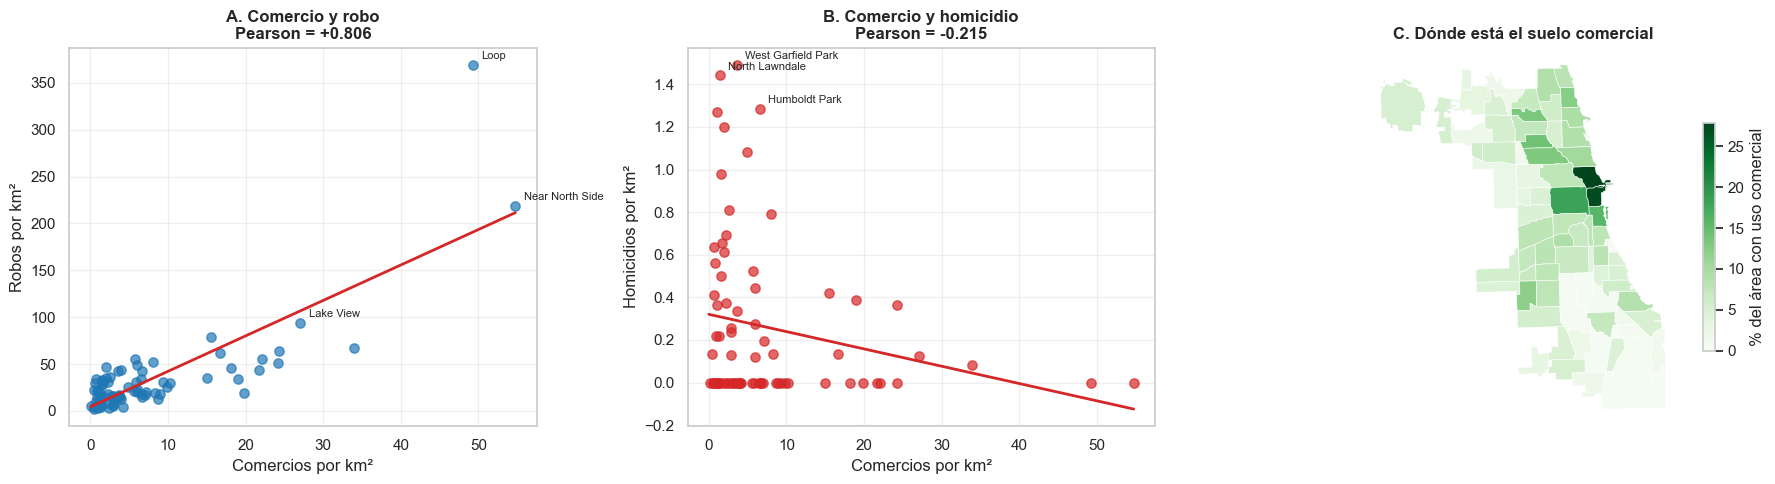

In [40]:
# ==============================================================================
#      VISUALIZACION DE LA ASOCIACION
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel A: comercios vs robos
ax = axes[0]
ax.scatter(tabla["comercios_km2"], tabla["robo_km2"], s=45, alpha=0.7, color="tab:blue")
for _, r in tabla.nlargest(3, "robo_km2").iterrows():
    ax.annotate(r["community"].title(), (r["comercios_km2"], r["robo_km2"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)
m, b = np.polyfit(tabla["comercios_km2"], tabla["robo_km2"], 1)
xs_l = np.linspace(0, tabla["comercios_km2"].max(), 50)
ax.plot(xs_l, m * xs_l + b, color="tab:red", lw=2)
r_rob = stats.pearsonr(tabla["comercios_km2"], tabla["robo_km2"]).statistic
ax.set_xlabel("Comercios por km²"); ax.set_ylabel("Robos por km²")
ax.set_title(f"A. Comercio y robo\nPearson = {r_rob:+.3f}", fontsize=12, fontweight="bold")
ax.grid(alpha=0.3)

# Panel B: comercios vs homicidios
ax = axes[1]
ax.scatter(tabla["comercios_km2"], tabla["homicidio_km2"], s=45, alpha=0.7, color="tab:red")
for _, r in tabla.nlargest(3, "homicidio_km2").iterrows():
    ax.annotate(r["community"].title(), (r["comercios_km2"], r["homicidio_km2"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)
m2, b2 = np.polyfit(tabla["comercios_km2"], tabla["homicidio_km2"], 1)
ax.plot(xs_l, m2 * xs_l + b2, color="tab:red", lw=2)
r_hom = stats.pearsonr(tabla["comercios_km2"], tabla["homicidio_km2"]).statistic
ax.set_xlabel("Comercios por km²"); ax.set_ylabel("Homicidios por km²")
ax.set_title(f"B. Comercio y homicidio\nPearson = {r_hom:+.3f}", fontsize=12, fontweight="bold")
ax.grid(alpha=0.3)

# Panel C: mapa del uso comercial
ax = axes[2]
areas_com = areas_m.merge(tabla[["nro_area_comunitaria", "com_pct"]],
                          left_on="area_num", right_on="nro_area_comunitaria", how="left")
areas_com.plot(column="com_pct", cmap="Greens", legend=True, edgecolor="white",
               linewidth=0.4, ax=ax,
               legend_kwds={"label": "% del área con uso comercial", "shrink": 0.6})
ax.set_title("C. Dónde está el suelo comercial", fontsize=12, fontweight="bold")
ax.set_axis_off()

plt.tight_layout()
plt.show()

**El uso comercial explica dónde ocurren los robos y no explica nada sobre los homicidios.**

La asociación con el robo es fuerte: la densidad de comercios correlaciona **+0,806** con la densidad de robos, y la proporción de suelo comercial **+0,726**. Con los homicidios el signo se invierte y la magnitud casi desaparece: **-0,215** y **-0,228**.

Es el contraste más nítido de todo el análisis, y coincide con lo que venimos viendo desde el Paso 1. Las áreas con más suelo comercial de la ciudad son Near North Side, con el 27,8%, y el Loop, con el 27,1%. Son también las dos con más robos, **y las dos con cero homicidios**.

**Conviene ser prudente con el signo negativo de los homicidios.** Las correlaciones son de -0,228 con p = 0,046 y de -0,215 con p = 0,060, es decir una apenas por debajo del umbral convencional y la otra apenas por encima. Con ocho contrastes realizados sobre las mismas 77 áreas, ninguna de las dos resiste una corrección por comparaciones múltiples. **Lo que estos datos sostienen es que el comercio no predice el homicidio, no que lo prevenga.**

**A diferencia del Paso 2, esta correlación no depende del centro.** Al excluir el Loop y Near North Side, la correlación entre comercios y robos baja de +0,806 a **+0,692**, y la del suelo comercial de +0,726 a +0,464. Se debilita, pero se mantiene claramente positiva y significativa. Recordemos que la correlación robo-homicidio del Paso 2 hacía lo contrario: pasaba de no significativa a moderada al quitar esos mismos dos barrios.

**El uso residencial no explica ninguno de los dos delitos.** Su correlación con la densidad de robos es de -0,193 y con la de homicidios de +0,025, ambas indistinguibles de cero en términos prácticos. Es un resultado útil por descarte: la concentración de homicidios no se explica ni por comercio ni por cuánto suelo residencial tiene el área.

## 6.2 Qué explicaciones son consistentes con este patrón

**Para el robo, la lectura más parsimoniosa es de exposición.** El robo requiere que coincidan en el espacio una víctima con algo de valor y alguien dispuesto a quitárselo. El suelo comercial concentra personas que salieron a comprar, con efectivo, teléfonos y bolsas. No hace falta suponer que el comercio "genera" delincuentes: basta con que concentre oportunidades.

Esa lectura es coherente con la teoría de actividades rutinarias, que explica el delito por la convergencia de un objetivo atractivo, un ofensor motivado y la ausencia de vigilancia eficaz.

**Para el homicidio, ninguna de las variables disponibles ofrece explicación.** El homicidio en Chicago se concentra en el corredor oeste y sur, en áreas que no destacan ni por comercio ni por proporción residencial. La literatura apunta a factores que estos datos no contienen: desventaja económica concentrada, presencia de pandillas, disponibilidad de armas, historia de segregación residencial. Nuestro análisis puede decir **dónde** ocurre y **con qué no se asocia**, pero no por qué.

## 6.3 Hasta dónde puede interpretarse esta evidencia

Esta es la sección más importante del paso, porque es donde un análisis como este suele desbordarse. Hay tres niveles distintos y solo alcanzamos el primero.

**Nivel 1: asociación espacial. Es lo que medimos.** En Chicago, en el verano de 2019, las áreas comunitarias con más comercio tuvieron más robos por kilómetro cuadrado. La correlación es de +0,806 y sobrevive a excluir el centro.

**Nivel 2: explicación causal. No lo medimos, y hay al menos cuatro razones para no afirmarlo.**

*El denominador está mal para la pregunta.* Medimos robos por kilómetro cuadrado, pero la exposición relevante es por persona presente. Las zonas comerciales tienen enormes poblaciones flotantes durante el día y casi ningún residente. Parte de la correlación es mecánica: donde hay más gente pasan más cosas. Sin datos de afluencia, como los del Paso 3, no se puede separar el efecto del comercio del efecto de la cantidad de gente.

*Hay selección en la ubicación del comercio.* Los comercios se instalan donde hay flujo peatonal, y el flujo peatonal atrae tanto comercio como robo. La correlación puede reflejar una causa común en vez de un vínculo directo.

*El agregado por área oculta la relación real.* Estamos correlacionando promedios de 77 unidades de 7,4 km² de mediana. Una asociación a ese nivel no implica que se sostenga a nivel de cuadra, que es donde patrulla una patrulla. Es la falacia ecológica.

*Los datos de OpenStreetMap tienen cobertura desigual.* Son contribuciones voluntarias, y las zonas céntricas y densas suelen estar mucho mejor mapeadas que las periféricas. Eso podría inflar la correlación por sí solo: más comercios registrados donde hay más actividad de todo tipo, incluido el mapeo. No podemos descartarlo con los datos que tenemos.

**Nivel 3: efectividad de una intervención. No lo tocamos siquiera.** Aunque el comercio causara el robo, no se sigue que patrullar zonas comerciales reduzca el robo. Podría desplazarlo a cuadras vecinas, podría no tener efecto, o podría tenerlo solo mientras la patrulla está presente. **Esa pregunta solo la responde un experimento**, y la literatura de puntos calientes tiene décadas de ensayos aleatorizados precisamente porque la asociación no bastaba.

## 6.4 Qué evidencia adicional haría falta

Para pasar de esta asociación a una recomendación de patrullaje fundamentada, en orden de esfuerzo creciente:

1. **Denominadores de exposición**: afluencia peatonal, población flotante, viajes en transporte público. Permitirían saber si las zonas comerciales son realmente más riesgosas o solo más concurridas.
2. **Análisis a escala fina**: repetir la asociación a nivel de segmento de calle en lugar de área comunitaria, para descartar la falacia ecológica.
3. **Variación temporal**: si el robo sigue el horario comercial y el homicidio no, la hipótesis de exposición gana respaldo. El dato de hora está en la base, aunque en UTC, como advertimos en el Paso 1.
4. **Controles socioeconómicos**: ingreso, desempleo, densidad residencial, para descartar que el comercio sea un indicador indirecto de otra cosa.
5. **Un ensayo aleatorizado o un cuasi-experimento** que asigne patrullaje adicional a un subconjunto de puntos calientes y compare contra controles, midiendo también las cuadras vecinas para detectar desplazamiento.

**Solo el punto 5 responde la pregunta que le importa al cliente**, que no es dónde ocurre el delito sino si patrullar allí lo reduce.

### Cierre del Paso 6

1. **Se usó `osmnx` en lugar de `pyrosm`**, que no es instalable en este entorno por un fallo de compilación de `cykhash`. Misma fuente de datos, distinta herramienta de acceso.
2. **Chicago tiene 35,3 km² de suelo comercial o minorista**, el 5,9% de la ciudad, y 4.165 comercios georreferenciados repartidos entre las 77 áreas.
3. **El uso comercial predice fuertemente el robo**: la densidad de comercios correlaciona +0,806 con la densidad de robos y la proporción de suelo comercial +0,726.
4. **No predice el homicidio**, y el signo se invierte: -0,215 con p = 0,060 y -0,228 con p = 0,046, ambas demasiado débiles para sostener nada tras ocho contrastes. Las dos áreas más comerciales de la ciudad, Near North Side con 27,8% y el Loop con 27,1%, tuvieron más de 1.500 robos cada una y **ningún homicidio**.
5. **La asociación con el robo no depende del centro.** Al excluir el Loop y Near North Side baja de +0,806 a +0,692, a diferencia de la correlación robo-homicidio del Paso 2, que hacía lo contrario.
6. **El uso residencial no explica ninguno de los dos delitos**, con correlaciones de -0,193 y +0,025.
7. **La lectura consistente para el robo es de exposición**: el comercio concentra oportunidades, no necesariamente ofensores.
8. **Para el homicidio, las variables disponibles no ofrecen explicación alguna.**
9. **La evidencia alcanza para afirmar asociación, no causalidad ni efectividad.** Cuatro razones lo impiden: el denominador es superficie y no exposición, el comercio se ubica donde hay flujo, el agregado por área puede incurrir en falacia ecológica, y la cobertura de OpenStreetMap es desigual.
10. **Que patrullar zonas comerciales reduzca el robo es una pregunta experimental**, no observacional, y ninguno de los procedimientos evaluados en este cuaderno puede responderla.